# NinaPro DB1: Complete Exploratory Data Analysis

## Objective

This notebook performs a detailed, track-neutral exploratory data analysis of the official **NinaPro DB1** dataset. It examines dataset structure, signal quality, descriptive statistics, class balance, feature distributions, correlations, dimensionality reduction, synchronized EMG–glove behaviour, repetition consistency, and subject variability.

The findings can later support a suitable project direction such as movement classification, hand-pose regression, within-subject modelling, or cross-subject generalization.

**Official sources**

- Dataset page: https://ninapro.hevs.ch/data/DB1.html
- Dataset description: https://ninapro.hevs.ch/instructions/DB1.html

DB1 contains synchronized surface EMG and CyberGlove recordings from 27 intact subjects. Each subject has three exercise files.

## 1. Setup

The notebook stores downloaded and extracted files in `/kaggle/working/`.  
Figures use consistent sizes, readable labels, and tight layouts.

In [17]:
from pathlib import Path
from collections import Counter, defaultdict
import hashlib
import math
import re
import subprocess
import sys
import warnings
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from IPython.display import display
from scipy.io import loadmat
from scipy.stats import skew, kurtosis
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 110,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

RANDOM_STATE = 42
SAMPLING_RATE_HZ = 100

BASE_URL = "https://ninapro.hevs.ch/files/DB1/Preprocessed"
WORK_DIR = Path("/kaggle/working/ninapro_db1")
DOWNLOAD_DIR = WORK_DIR / "zip_files"
EXTRACT_DIR = WORK_DIR / "mat_files"

DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(RANDOM_STATE)

print("Working directory:", WORK_DIR)

Working directory: /kaggle/working/ninapro_db1


## 2. Download and extract the official dataset

The cell downloads each subject ZIP only when it is not already available.  
A valid extracted subject folder is also skipped.

In [9]:
for subject in range(1, 28):
    filename = f"s{subject}.zip"
    url = f"{BASE_URL}/{filename}"
    zip_path = DOWNLOAD_DIR / filename
    subject_dir = EXTRACT_DIR / f"s{subject}"

    existing_mat = list(subject_dir.rglob("*.mat")) if subject_dir.exists() else []

    if existing_mat:
        print(f"[{subject:02d}/27] Extracted files already available")
        continue

    if not (zip_path.exists() and zipfile.is_zipfile(zip_path)):
        zip_path.unlink(missing_ok=True)

        response = requests.get(url, stream=True, timeout=300)
        response.raise_for_status()

        with open(zip_path, "wb") as file:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    file.write(chunk)

        if not zipfile.is_zipfile(zip_path):
            raise RuntimeError(f"Invalid ZIP downloaded: {filename}")

        print(f"[{subject:02d}/27] Downloaded {filename}")
    else:
        print(f"[{subject:02d}/27] ZIP already available")

    subject_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as archive:
        archive.extractall(subject_dir)

mat_files = sorted(EXTRACT_DIR.rglob("*.mat"))

print("\nTotal MATLAB files:", len(mat_files))

if len(mat_files) == 81:
    print("Dataset file count verified: 27 subjects × 3 exercises.")
else:
    print("Warning: DB1 is expected to contain 81 MATLAB files.")

[01/27] Downloaded s1.zip
[02/27] Downloaded s2.zip
[03/27] Downloaded s3.zip
[04/27] Downloaded s4.zip
[05/27] Downloaded s5.zip
[06/27] Downloaded s6.zip
[07/27] Downloaded s7.zip
[08/27] Downloaded s8.zip
[09/27] Downloaded s9.zip
[10/27] Downloaded s10.zip
[11/27] Downloaded s11.zip
[12/27] Downloaded s12.zip
[13/27] Downloaded s13.zip
[14/27] Downloaded s14.zip
[15/27] Downloaded s15.zip
[16/27] Downloaded s16.zip
[17/27] Downloaded s17.zip
[18/27] Downloaded s18.zip
[19/27] Downloaded s19.zip
[20/27] Downloaded s20.zip
[21/27] Downloaded s21.zip
[22/27] Downloaded s22.zip
[23/27] Downloaded s23.zip
[24/27] Downloaded s24.zip
[25/27] Downloaded s25.zip
[26/27] Downloaded s26.zip
[27/27] Downloaded s27.zip

Total MATLAB files: 81
Dataset file count verified: 27 subjects × 3 exercises.


## 3. Helper functions

These functions read the variables found inside each MATLAB file, identify synchronized signals and annotations from their shapes, and extract subject/exercise identifiers from filenames.

In [16]:
def load_arrays(file_path):
    raw = loadmat(file_path, squeeze_me=True, struct_as_record=False)

    return {
        name: np.asarray(values)
        for name, values in raw.items()
        if not name.startswith("__")
    }


def parse_file_ids(file_path):
    name = Path(file_path).stem

    def find_id(letter):
        match = re.search(fr"{letter}(\d+)", name, flags=re.IGNORECASE)
        return int(match.group(1)) if match else np.nan

    return {
        "subject_id": find_id("S"),
        "exercise_id": find_id("E"),
        "acquisition_id": find_id("A")
    }


def detect_layout(data):
    arrays = {
        name: np.squeeze(values)
        for name, values in data.items()
        if np.asarray(values).ndim >= 1 and np.asarray(values).size > 1
    }

    first_dimensions = [
        values.shape[0]
        for values in arrays.values()
        if values.ndim >= 1
    ]

    if not first_dimensions:
        raise ValueError("No time-dependent arrays were found.")

    n_samples = max(first_dimensions)

    signals = [
        name for name, values in arrays.items()
        if values.ndim == 2
        and values.shape[0] == n_samples
        and values.shape[1] > 1
        and np.issubdtype(values.dtype, np.number)
    ]

    annotations = [
        name for name, values in arrays.items()
        if values.ndim == 1
        and values.shape[0] == n_samples
        and np.issubdtype(values.dtype, np.number)
    ]

    lower_to_original = {name.lower(): name for name in annotations}

    label_key = next(
        (lower_to_original[name] for name in ["restimulus", "stimulus"]
         if name in lower_to_original),
        None
    )

    repetition_key = next(
        (lower_to_original[name] for name in ["rerepetition", "repetition"]
         if name in lower_to_original),
        None
    )

    return {
        "n_samples": n_samples,
        "signals": signals,
        "annotations": annotations,
        "label_key": label_key,
        "repetition_key": repetition_key
    }


def channel_names(data, signal_keys):
    groups = {}

    for key in signal_keys:
        groups[key] = [
            f"{key}_ch{channel + 1:02d}"
            for channel in range(data[key].shape[1])
        ]

    return groups


def mode_value(values):
    unique_values, counts = np.unique(values, return_counts=True)
    return unique_values[np.argmax(counts)]

# A. Dataset summary and structure

## A1. Variables in a sample file

In [14]:
sample_file = mat_files[0]
sample_data = load_arrays(sample_file)
sample_layout = detect_layout(sample_data)

structure_rows = []

for name, values in sample_data.items():
    structure_rows.append({
        "Variable": name,
        "Shape": str(values.shape),
        "Dimensions": values.ndim,
        "Data type": str(values.dtype),
        "Total values": values.size
    })

structure_df = pd.DataFrame(structure_rows)

print("Sample file:", sample_file.name)
print("Detected signal matrices:", sample_layout["signals"])
print("Detected annotation arrays:", sample_layout["annotations"])
print("Selected movement annotation:", sample_layout["label_key"])
print("Selected repetition annotation:", sample_layout["repetition_key"])

display(structure_df)

Sample file: S1_A1_E1.mat
Detected signal matrices: ['emg', 'glove']
Detected annotation arrays: ['stimulus', 'repetition', 'restimulus', 'rerepetition']
Selected movement annotation: restimulus
Selected repetition annotation: rerepetition


,Variable,Shape,Dimensions,Data type,Total values
0,emg,"(101014, 10)",2,float64,1010140
1,stimulus,"(101014,)",1,uint8,101014
2,glove,"(101014, 22)",2,float64,2222308
3,subject,(),0,int64,1
4,exercise,(),0,int64,1
5,repetition,"(101014,)",1,uint8,101014
6,restimulus,"(101014,)",1,uint8,101014
7,rerepetition,"(101014,)",1,uint8,101014


## A2. File inventory, synchronization, missing values, and duplicate rows

Each file is processed separately, so the complete raw dataset does not need to be combined into one large table.

In [19]:
inventory_records = []
class_counts = Counter()
repetition_counts = Counter()
file_hashes = Counter()

for position, file_path in enumerate(mat_files, start=1):
    data = load_arrays(file_path)
    layout = detect_layout(data)
    ids = parse_file_ids(file_path)

    time_lengths = {
        name: np.squeeze(values).shape[0]
        for name, values in data.items()
        if np.asarray(values).ndim >= 1
        and np.asarray(values).size > 1
        and np.squeeze(values).ndim >= 1
    }

    relevant_lengths = list(time_lengths.values())

    missing_count = 0
    infinite_count = 0
    signal_shapes = {}
    signal_matrices = []

    for key in layout["signals"]:
        matrix = np.asarray(data[key])
        signal_shapes[key] = str(matrix.shape)
        missing_count += int(np.isnan(matrix).sum())
        infinite_count += int(np.isinf(matrix).sum())
        signal_matrices.append(matrix)

    duplicate_rows = 0
    if signal_matrices:
        combined_signals = np.column_stack(signal_matrices)
        duplicate_rows = int(pd.DataFrame(combined_signals).duplicated().sum())

    if layout["label_key"] is not None:
        labels = np.asarray(data[layout["label_key"]]).reshape(-1).astype(int)
        values, counts = np.unique(labels, return_counts=True)
        class_counts.update(dict(zip(values.tolist(), counts.tolist())))

    if layout["repetition_key"] is not None:
        repetitions = np.asarray(data[layout["repetition_key"]]).reshape(-1).astype(int)
        values, counts = np.unique(repetitions, return_counts=True)
        repetition_counts.update(dict(zip(values.tolist(), counts.tolist())))

    with open(file_path, "rb") as file:
        file_hash = hashlib.md5(file.read()).hexdigest()
    file_hashes[file_hash] += 1

    inventory_records.append({
        "File": file_path.name,
        **ids,
        "Samples": layout["n_samples"],
        "Duration_min": layout["n_samples"] / SAMPLING_RATE_HZ / 60,
        "Signal_variables": ", ".join(layout["signals"]),
        "Signal_shapes": signal_shapes,
        "Annotation_variables": ", ".join(layout["annotations"]),
        "Aligned": len(set(relevant_lengths)) == 1 and len(relevant_lengths) > 0,
        "Missing_values": missing_count,
        "Infinite_values": infinite_count,
        "Duplicate_signal_rows": duplicate_rows,
        "Duplicate_row_percent": 100 * duplicate_rows / layout["n_samples"]
    })

    if position % 10 == 0 or position == len(mat_files):
        print(f"Processed {position}/{len(mat_files)} files")

inventory_df = pd.DataFrame(inventory_records).sort_values(
    ["subject_id", "exercise_id", "File"]
).reset_index(drop=True)

display(inventory_df.head(10))

Processed 10/81 files
Processed 20/81 files
Processed 30/81 files
Processed 40/81 files
Processed 50/81 files
Processed 60/81 files
Processed 70/81 files
Processed 80/81 files
Processed 81/81 files


,File,subject_id,exercise_id,acquisition_id,Samples,Duration_min,Signal_variables,Signal_shapes,Annotation_variables,Aligned,Missing_values,Infinite_values,Duplicate_signal_rows,Duplicate_row_percent
0,S1_A1_E1.mat,1,1,1,101014,16.835667,"emg, glove","{'emg': '(101014, 10)', 'glove': '(101014, 22)'}","stimulus, repetition, restimulus, rerepetition",True,0,0,4661,4.614212
1,S1_A1_E2.mat,1,2,1,142976,23.829333,"emg, glove","{'emg': '(142976, 10)', 'glove': '(142976, 22)'}","stimulus, repetition, restimulus, rerepetition",True,0,0,4442,3.106815
2,S1_A1_E3.mat,1,3,1,227493,37.915500,"emg, glove","{'emg': '(227493, 10)', 'glove': '(227493, 22)'}","stimulus, repetition, restimulus, rerepetition",True,0,0,1193,0.524412
3,S2_A1_E1.mat,2,1,1,100686,16.781000,"emg, glove","{'emg': '(100686, 10)', 'glove': '(100686, 22)'}","stimulus, restimulus, repetition, rerepetition",True,0,0,3107,3.085831
4,S2_A1_E2.mat,2,2,1,142731,23.788500,"emg, glove","{'emg': '(142731, 10)', 'glove': '(142731, 22)'}","stimulus, restimulus, repetition, rerepetition",True,0,0,2374,1.663269
5,S2_A1_E3.mat,2,3,1,229084,38.180667,"emg, glove","{'emg': '(229084, 10)', 'glove': '(229084, 22)'}","stimulus, restimulus, repetition, rerepetition",True,0,0,1715,0.748634
6,S3_A1_E1.mat,3,1,1,100720,16.786667,"emg, glove","{'emg': '(100720, 10)', 'glove': '(100720, 22)'}","stimulus, restimulus, repetition, rerepetition",True,0,0,8133,8.074861
7,S3_A1_E2.mat,3,2,1,142682,23.780333,"emg, glove","{'emg': '(142682, 10)', 'glove': '(142682, 22)'}","stimulus, restimulus, repetition, rerepetition",True,0,0,8893,6.232741
8,S3_A1_E3.mat,3,3,1,224375,37.395833,"emg, glove","{'emg': '(224375, 10)', 'glove': '(224375, 22)'}","stimulus, restimulus, repetition, rerepetition",True,0,0,11309,5.040223
9,S4_A1_E1.mat,4,1,1,100835,16.805833,"emg, glove","{'emg': '(100835, 10)', 'glove': '(100835, 22)'}","stimulus, restimulus, repetition, rerepetition",True,0,0,3679,3.648535


In [20]:
all_signal_names = sorted({
    signal
    for text in inventory_df["Signal_variables"]
    for signal in [item.strip() for item in text.split(",") if item.strip()]
})

all_annotation_names = sorted({
    annotation
    for text in inventory_df["Annotation_variables"]
    for annotation in [item.strip() for item in text.split(",") if item.strip()]
})

sample_groups = channel_names(sample_data, sample_layout["signals"])
feature_count = sum(len(columns) for columns in sample_groups.values())

active_classes = sorted(label for label in class_counts if label != 0)
duplicate_file_count = sum(count - 1 for count in file_hashes.values() if count > 1)

summary_df = pd.DataFrame({
    "Item": [
        "Dataset name",
        "Source",
        "Area",
        "MATLAB files",
        "Total samples",
        "Total duration (hours)",
        "Subjects",
        "Exercises",
        "Movement classes",
        "Rest label",
        "Signal variables",
        "Feature/channel count",
        "Feature type",
        "Class balance",
        "Missing values",
        "Infinite values",
        "Duplicate files",
        "Duplicate signal rows"
    ],
    "Result": [
        "NinaPro DB1",
        "Official NinaPro repository",
        "Surface EMG and hand kinematics",
        f"{len(inventory_df):,}",
        f"{inventory_df['Samples'].sum():,}",
        f"{inventory_df['Duration_min'].sum() / 60:,.2f}",
        int(inventory_df["subject_id"].nunique()),
        int(inventory_df["exercise_id"].nunique()),
        len(active_classes),
        "0" if 0 in class_counts else "Not detected",
        ", ".join(all_signal_names),
        feature_count,
        "Continuous synchronized time-series signals",
        "Reported in Section D",
        f"{inventory_df['Missing_values'].sum():,}",
        f"{inventory_df['Infinite_values'].sum():,}",
        duplicate_file_count,
        f"{inventory_df['Duplicate_signal_rows'].sum():,}"
    ]
})

display(summary_df)

,Item,Result
0,Dataset name,NinaPro DB1
1,Source,Official NinaPro repository
2,Area,Surface EMG and hand kinematics
3,MATLAB files,81
4,Total samples,"12,553,611"
5,Total duration (hours),34.87
6,Subjects,27
7,Exercises,3
8,Movement classes,23
9,Rest label,0


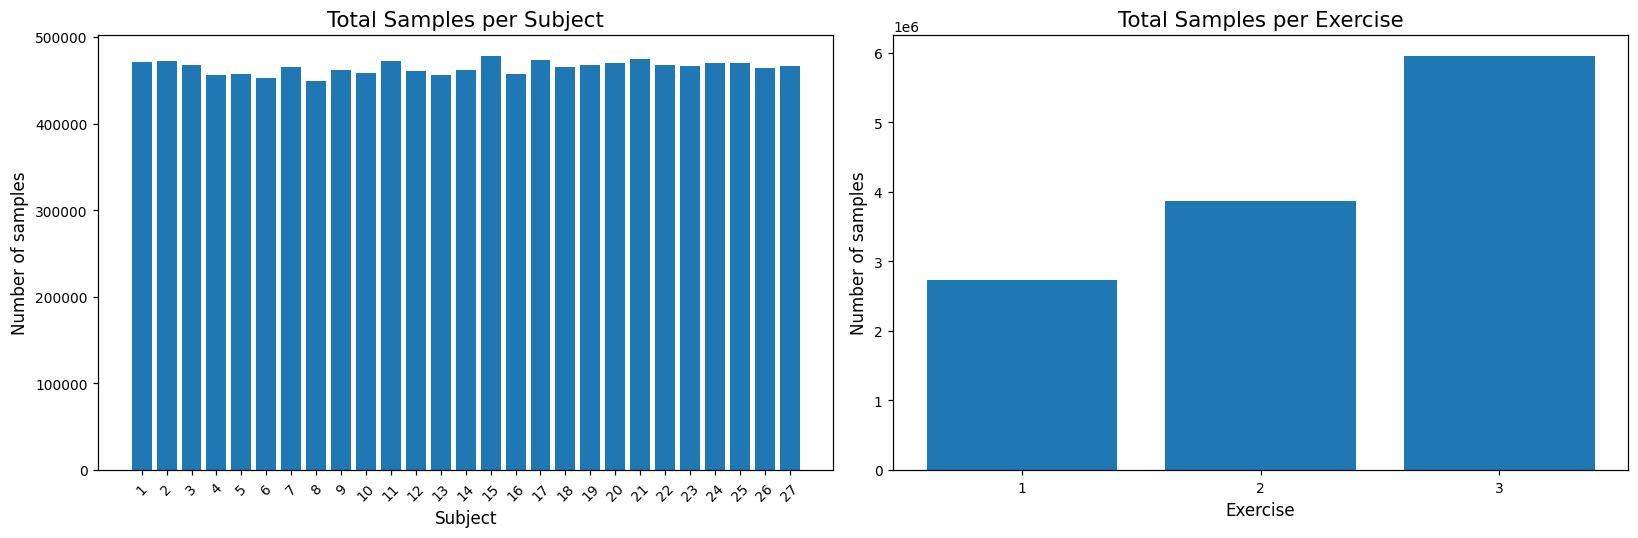

Reading: the largest subject recording contains 1.06 times as many samples as the smallest subject recording.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

subject_samples = inventory_df.groupby("subject_id")["Samples"].sum()
exercise_samples = inventory_df.groupby("exercise_id")["Samples"].sum()

axes[0].bar(subject_samples.index.astype(str), subject_samples.values)
axes[0].set_title("Total Samples per Subject")
axes[0].set_xlabel("Subject")
axes[0].set_ylabel("Number of samples")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(exercise_samples.index.astype(str), exercise_samples.values)
axes[1].set_title("Total Samples per Exercise")
axes[1].set_xlabel("Exercise")
axes[1].set_ylabel("Number of samples")

plt.tight_layout()
plt.show()

subject_ratio = subject_samples.max() / subject_samples.min()
print(
    f"Reading: the largest subject recording contains {subject_ratio:.2f} times "
    "as many samples as the smallest subject recording."
)

## A3. Analysis sample

Dataset-level statistics and distribution plots use a reproducible sample from every file. Exact file counts and class counts above still use all observations.

In [22]:
ROWS_PER_FILE = 4000
sampled_parts = []

for file_path in mat_files:
    data = load_arrays(file_path)
    layout = detect_layout(data)
    ids = parse_file_ids(file_path)

    n_samples = layout["n_samples"]
    chosen = rng.choice(
        n_samples,
        size=min(ROWS_PER_FILE, n_samples),
        replace=False
    )

    part = pd.DataFrame()

    for key in layout["signals"]:
        matrix = np.asarray(data[key])
        for channel in range(matrix.shape[1]):
            part[f"{key}_ch{channel + 1:02d}"] = matrix[chosen, channel]

    part["subject_id"] = ids["subject_id"]
    part["exercise_id"] = ids["exercise_id"]
    part["file"] = file_path.name

    if layout["label_key"] is not None:
        part["class_label"] = (
            np.asarray(data[layout["label_key"]]).reshape(-1)[chosen].astype(int)
        )

    if layout["repetition_key"] is not None:
        part["repetition"] = (
            np.asarray(data[layout["repetition_key"]]).reshape(-1)[chosen].astype(int)
        )

    sampled_parts.append(part)

sampled_df = pd.concat(sampled_parts, ignore_index=True)

metadata_columns = {
    "subject_id", "exercise_id", "file", "class_label", "repetition"
}
feature_columns = [
    column for column in sampled_df.columns
    if column not in metadata_columns
    and pd.api.types.is_numeric_dtype(sampled_df[column])
]

signal_groups = {
    key: [column for column in feature_columns if column.startswith(f"{key}_ch")]
    for key in sample_layout["signals"]
}
signal_groups = {
    key: columns for key, columns in signal_groups.items() if columns
}

print("Sampled rows:", f"{len(sampled_df):,}")
print("Continuous features:", len(feature_columns))
display(sampled_df.head())

Sampled rows: 324,000
Continuous features: 32


,emg_ch01,emg_ch02,emg_ch03,emg_ch04,emg_ch05,emg_ch06,emg_ch07,emg_ch08,emg_ch09,emg_ch10,glove_ch01,glove_ch02,glove_ch03,glove_ch04,glove_ch05,glove_ch06,glove_ch07,glove_ch08,glove_ch09,glove_ch10,glove_ch11,glove_ch12,glove_ch13,glove_ch14,glove_ch15,glove_ch16,glove_ch17,glove_ch18,glove_ch19,glove_ch20,glove_ch21,glove_ch22,subject_id,exercise_id,file,class_label,repetition
0,0.0195,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0562,0.0024,0.0024,138.0,141.000000,108.000000,139.000000,125.00000,74.000000,69.000000,119.0,89.0,70.0,149.0,119.0,85.0,58.0,159.915268,131.0,67.0,62.0,114.0,127.000000,133.0,110.0,1,1,S1_A1_E1.mat,0,0
1,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0708,0.1587,0.0024,0.0220,130.0,122.946284,120.946284,131.684572,134.00000,75.000000,68.000000,118.0,91.0,68.0,153.0,120.0,81.0,63.0,172.000000,110.0,89.0,67.0,149.0,136.000000,131.0,116.0,1,1,S1_A1_E1.mat,0,0
2,0.0049,0.0220,0.1099,0.0073,0.0024,0.0024,0.1367,0.0781,0.0024,0.0024,177.0,137.000000,56.000000,128.000000,125.00000,77.000000,67.000000,133.0,66.0,76.0,138.0,146.0,71.0,73.0,208.000000,130.0,70.0,66.0,163.0,175.000000,124.0,118.0,1,1,S1_A1_E1.mat,10,8
3,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0171,0.0439,0.0024,0.0195,164.0,137.000000,129.000000,127.000000,118.85033,87.000000,68.000000,105.0,87.0,68.0,147.0,115.0,82.0,65.0,170.000000,106.0,82.0,69.0,148.0,156.000000,131.0,116.0,1,1,S1_A1_E1.mat,0,0
4,0.0903,0.9619,0.2417,0.0146,0.0171,0.0659,1.9849,0.3809,0.4492,0.1099,142.0,120.000000,109.000000,128.000000,125.00000,68.113812,64.886188,54.0,49.0,92.0,156.0,108.0,88.0,46.0,42.000000,109.0,90.0,73.0,137.0,129.886188,135.0,116.0,1,1,S1_A1_E1.mat,4,9


# B. Descriptive statistics

In [24]:
basic_stats = sampled_df[feature_columns].describe(
    percentiles=[0.25, 0.50, 0.75]
).T

basic_stats = basic_stats.rename(columns={
    "25%": "Q1",
    "50%": "Median",
    "75%": "Q3",
    "std": "Std",
    "min": "Min",
    "max": "Max",
    "mean": "Mean"
})

basic_stats["IQR"] = basic_stats["Q3"] - basic_stats["Q1"]
basic_stats["Skewness"] = sampled_df[feature_columns].skew()
basic_stats["Kurtosis"] = sampled_df[feature_columns].kurtosis()

lower_limits = basic_stats["Q1"] - 1.5 * basic_stats["IQR"]
upper_limits = basic_stats["Q3"] + 1.5 * basic_stats["IQR"]

outlier_counts = {}
for column in feature_columns:
    values = sampled_df[column]
    outlier_counts[column] = int(
        ((values < lower_limits[column]) | (values > upper_limits[column])).sum()
    )

basic_stats["Outlier_count"] = pd.Series(outlier_counts)
basic_stats["Outlier_percent"] = (
    100 * basic_stats["Outlier_count"] / len(sampled_df)
)

statistics_df = basic_stats[[
    "Mean", "Median", "Std", "Min", "Q1", "Q3", "Max",
    "IQR", "Skewness", "Kurtosis", "Outlier_count", "Outlier_percent"
]].round(4)

display(statistics_df)

,Mean,Median,Std,Min,Q1,Q3,Max,IQR,Skewness,Kurtosis,Outlier_count,Outlier_percent
emg_ch01,0.2293,0.0537,0.4161,0.0000,0.0049,0.2734,4.6680,0.2685,3.7384,21.2627,32133,9.9176
emg_ch02,0.1403,0.0049,0.2957,0.0000,0.0024,0.1489,4.6631,0.1465,4.5010,33.4581,39760,12.2716
emg_ch03,0.1283,0.0049,0.3399,0.0024,0.0024,0.0977,4.6606,0.0953,5.9329,50.3980,48652,15.0160
emg_ch04,0.0645,0.0024,0.2071,0.0000,0.0024,0.0244,4.6655,0.0220,8.2737,107.7605,64403,19.8775
emg_ch05,0.0225,0.0024,0.0840,0.0024,0.0024,0.0049,4.6631,0.0025,20.6783,802.4878,72941,22.5127
emg_ch06,0.0568,0.0049,0.1622,0.0000,0.0024,0.0464,4.6655,0.0440,8.8782,124.7175,42418,13.0920
emg_ch07,0.3209,0.1270,0.5573,0.0024,0.0220,0.3638,4.6655,0.3418,3.8946,20.0445,29959,9.2466
emg_ch08,0.3300,0.1831,0.4520,0.0024,0.0635,0.4150,4.6680,0.3515,3.5899,19.9603,24224,7.4765
emg_ch09,0.1273,0.0024,0.3376,0.0000,0.0024,0.0952,4.6631,0.0928,5.7722,47.7508,46894,14.4735
emg_ch10,0.2347,0.1001,0.3877,0.0000,0.0098,0.2881,4.6655,0.2783,4.1668,26.8040,25352,7.8247


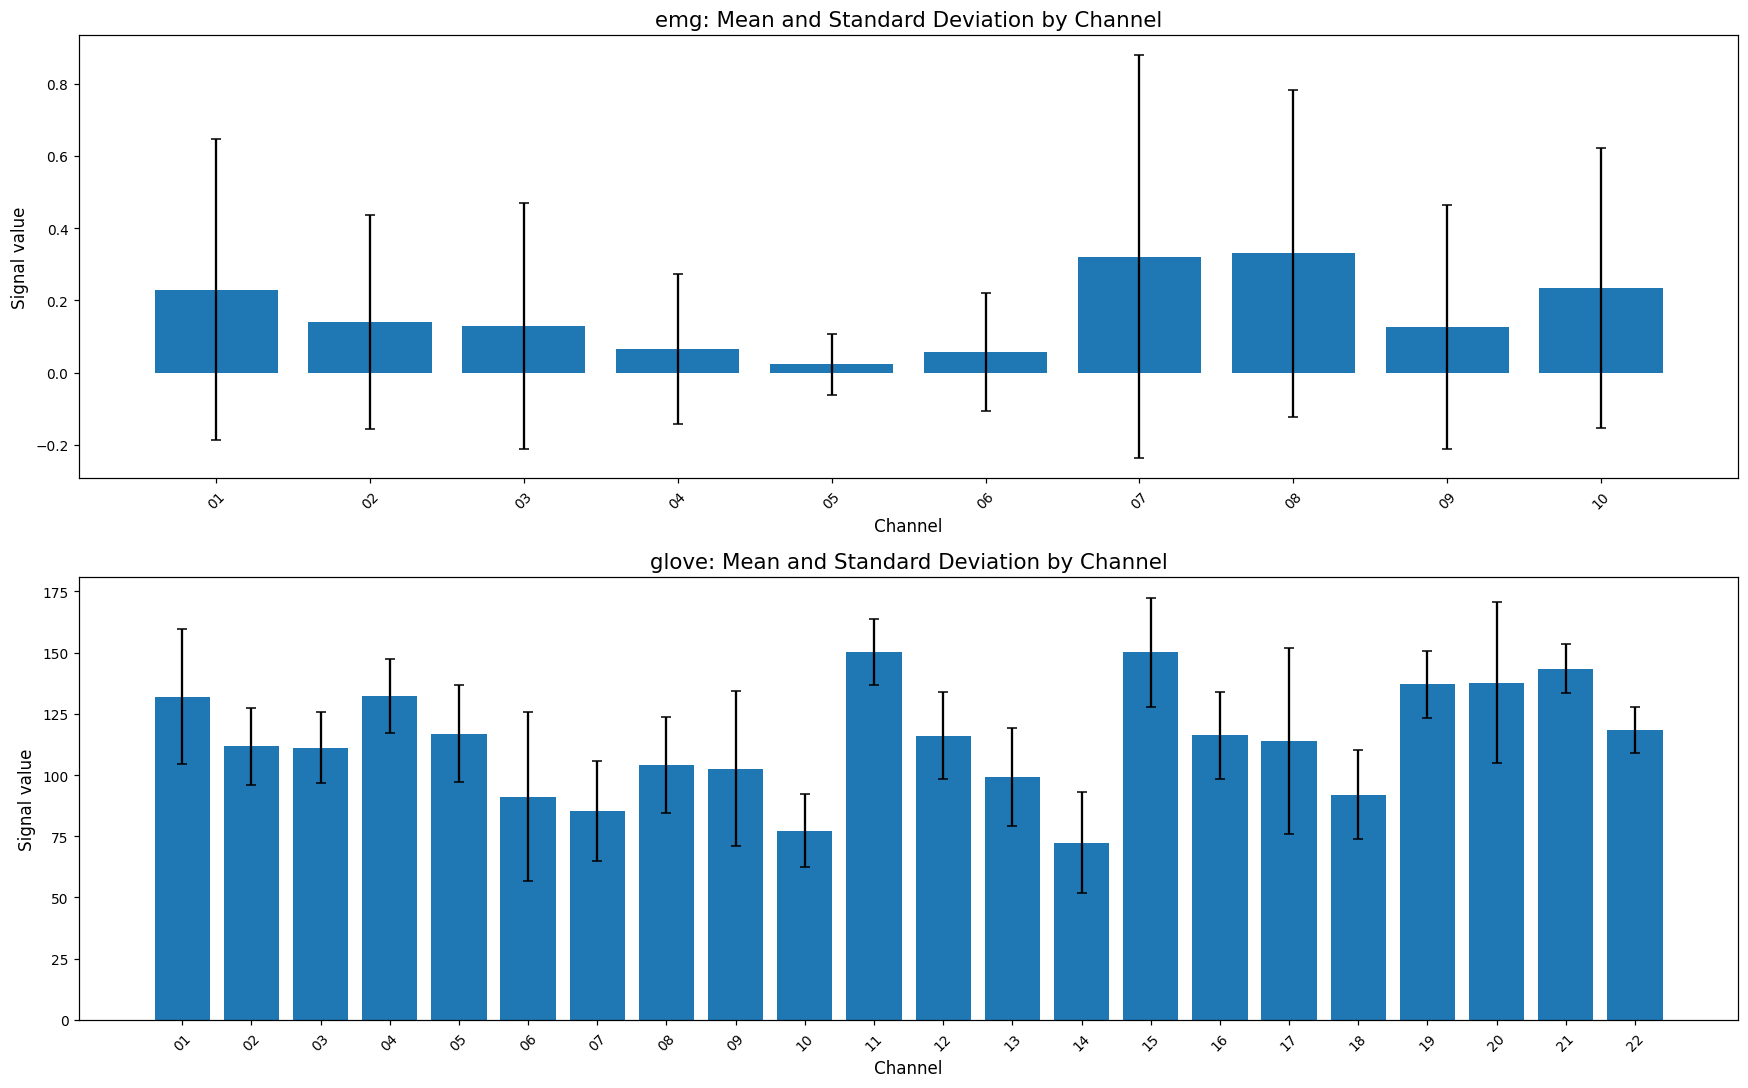

Reading: emg_ch05 has the strongest absolute skewness (20.68).


In [25]:
fig, axes = plt.subplots(
    len(signal_groups),
    1,
    figsize=(16, 5 * len(signal_groups)),
    squeeze=False
)

for row, (group_name, columns) in enumerate(signal_groups.items()):
    group_means = statistics_df.loc[columns, "Mean"]
    group_stds = statistics_df.loc[columns, "Std"]

    positions = np.arange(len(columns))
    axes[row, 0].bar(positions, group_means.values, yerr=group_stds.values, capsize=3)
    axes[row, 0].set_title(f"{group_name}: Mean and Standard Deviation by Channel")
    axes[row, 0].set_xlabel("Channel")
    axes[row, 0].set_ylabel("Signal value")
    axes[row, 0].set_xticks(positions)
    axes[row, 0].set_xticklabels(
        [column.split("_ch")[-1] for column in columns],
        rotation=45
    )

plt.tight_layout()
plt.show()

most_skewed = statistics_df["Skewness"].abs().idxmax()
print(
    f"Reading: {most_skewed} has the strongest absolute skewness "
    f"({statistics_df.loc[most_skewed, 'Skewness']:.2f})."
)

# C. Data quality and modelling implications

In [26]:
quality_overview = pd.DataFrame({
    "Check": [
        "Missing values",
        "Infinite values",
        "Duplicate files",
        "Repeated signal rows",
        "Near-constant features",
        "Highly correlated features",
        "IQR outliers"
    ],
    "What it can affect": [
        "Scaling, feature extraction, and model fitting",
        "Numerical stability and loss calculations",
        "Train/test leakage and over-optimistic results",
        "Possible leakage if duplicated trials cross data splits; stable poses can also repeat naturally",
        "Adds little information and can increase computation",
        "Creates redundancy and may affect linear models",
        "Can distort means and scaling, but large EMG values may be valid muscle activity"
    ]
})

display(quality_overview)

,Check,What it can affect
0,Missing values,"Scaling, feature extraction, and model fitting"
1,Infinite values,Numerical stability and loss calculations
2,Duplicate files,Train/test leakage and over-optimistic results
3,Repeated signal rows,Possible leakage if duplicated trials cross da...
4,Near-constant features,Adds little information and can increase compu...
5,Highly correlated features,Creates redundancy and may affect linear models
6,IQR outliers,"Can distort means and scaling, but large EMG v..."


In [27]:
near_constant_rows = []

for column in feature_columns:
    values = sampled_df[column]
    value_counts = values.value_counts(dropna=False)

    near_constant_rows.append({
        "Feature": column,
        "Standard_deviation": values.std(),
        "Unique_values": values.nunique(dropna=False),
        "Dominant_value_percent": 100 * value_counts.iloc[0] / len(values),
        "Near_constant": (
            values.std() <= 1e-8
            or value_counts.iloc[0] / len(values) >= 0.99
        )
    })

near_constant_df = pd.DataFrame(near_constant_rows)
near_constant_features = near_constant_df[
    near_constant_df["Near_constant"]
].reset_index(drop=True)

print("Near-constant features found:", len(near_constant_features))
display(near_constant_features)

Near-constant features found: 0


,Feature,Standard_deviation,Unique_values,Dominant_value_percent,Near_constant


In [28]:
quality_by_file = inventory_df[[
    "File", "Missing_values", "Infinite_values",
    "Duplicate_signal_rows", "Duplicate_row_percent", "Aligned"
]].copy()

display(
    quality_by_file.sort_values(
        ["Missing_values", "Infinite_values", "Duplicate_row_percent"],
        ascending=False
    ).head(15)
)

print(
    "Reading:",
    f"{(~inventory_df['Aligned']).sum()} files have a synchronization warning; "
    f"{inventory_df['Missing_values'].sum():,} missing values and "
    f"{inventory_df['Infinite_values'].sum():,} infinite values were detected."
)

,File,Missing_values,Infinite_values,Duplicate_signal_rows,Duplicate_row_percent,Aligned
22,S8_A1_E2.mat,0,0,20655,14.467021,True
6,S3_A1_E1.mat,0,0,8133,8.074861,True
21,S8_A1_E1.mat,0,0,7169,7.108295,True
55,S19_A1_E2.mat,0,0,9011,6.301443,True
7,S3_A1_E2.mat,0,0,8893,6.232741,True
62,S21_A1_E3.mat,0,0,12751,5.580722,True
8,S3_A1_E3.mat,0,0,11309,5.040223,True
56,S19_A1_E3.mat,0,0,11176,5.011861,True
0,S1_A1_E1.mat,0,0,4661,4.614212,True
50,S17_A1_E3.mat,0,0,10369,4.548206,True


Reading: 0 files have a synchronization warning; 0 missing values and 0 infinite values were detected.


# D. Class balance

In [29]:
class_balance_df = pd.DataFrame(
    sorted(class_counts.items()),
    columns=["Class", "Samples"]
)

class_balance_df["Percentage"] = (
    100 * class_balance_df["Samples"] / class_balance_df["Samples"].sum()
)
class_balance_df["Duration_min"] = (
    class_balance_df["Samples"] / SAMPLING_RATE_HZ / 60
)

display(class_balance_df)

,Class,Samples,Percentage,Duration_min
0,0,7290845,58.077672,1215.140833
1,1,303720,2.419384,50.620000
2,2,299072,2.382358,49.845333
3,3,307321,2.448069,51.220167
4,4,290830,2.316704,48.471667
5,5,287942,2.293699,47.990333
6,6,292612,2.330899,48.768667
7,7,298404,2.377037,49.734000
8,8,303280,2.415879,50.546667
9,9,297929,2.373253,49.654833


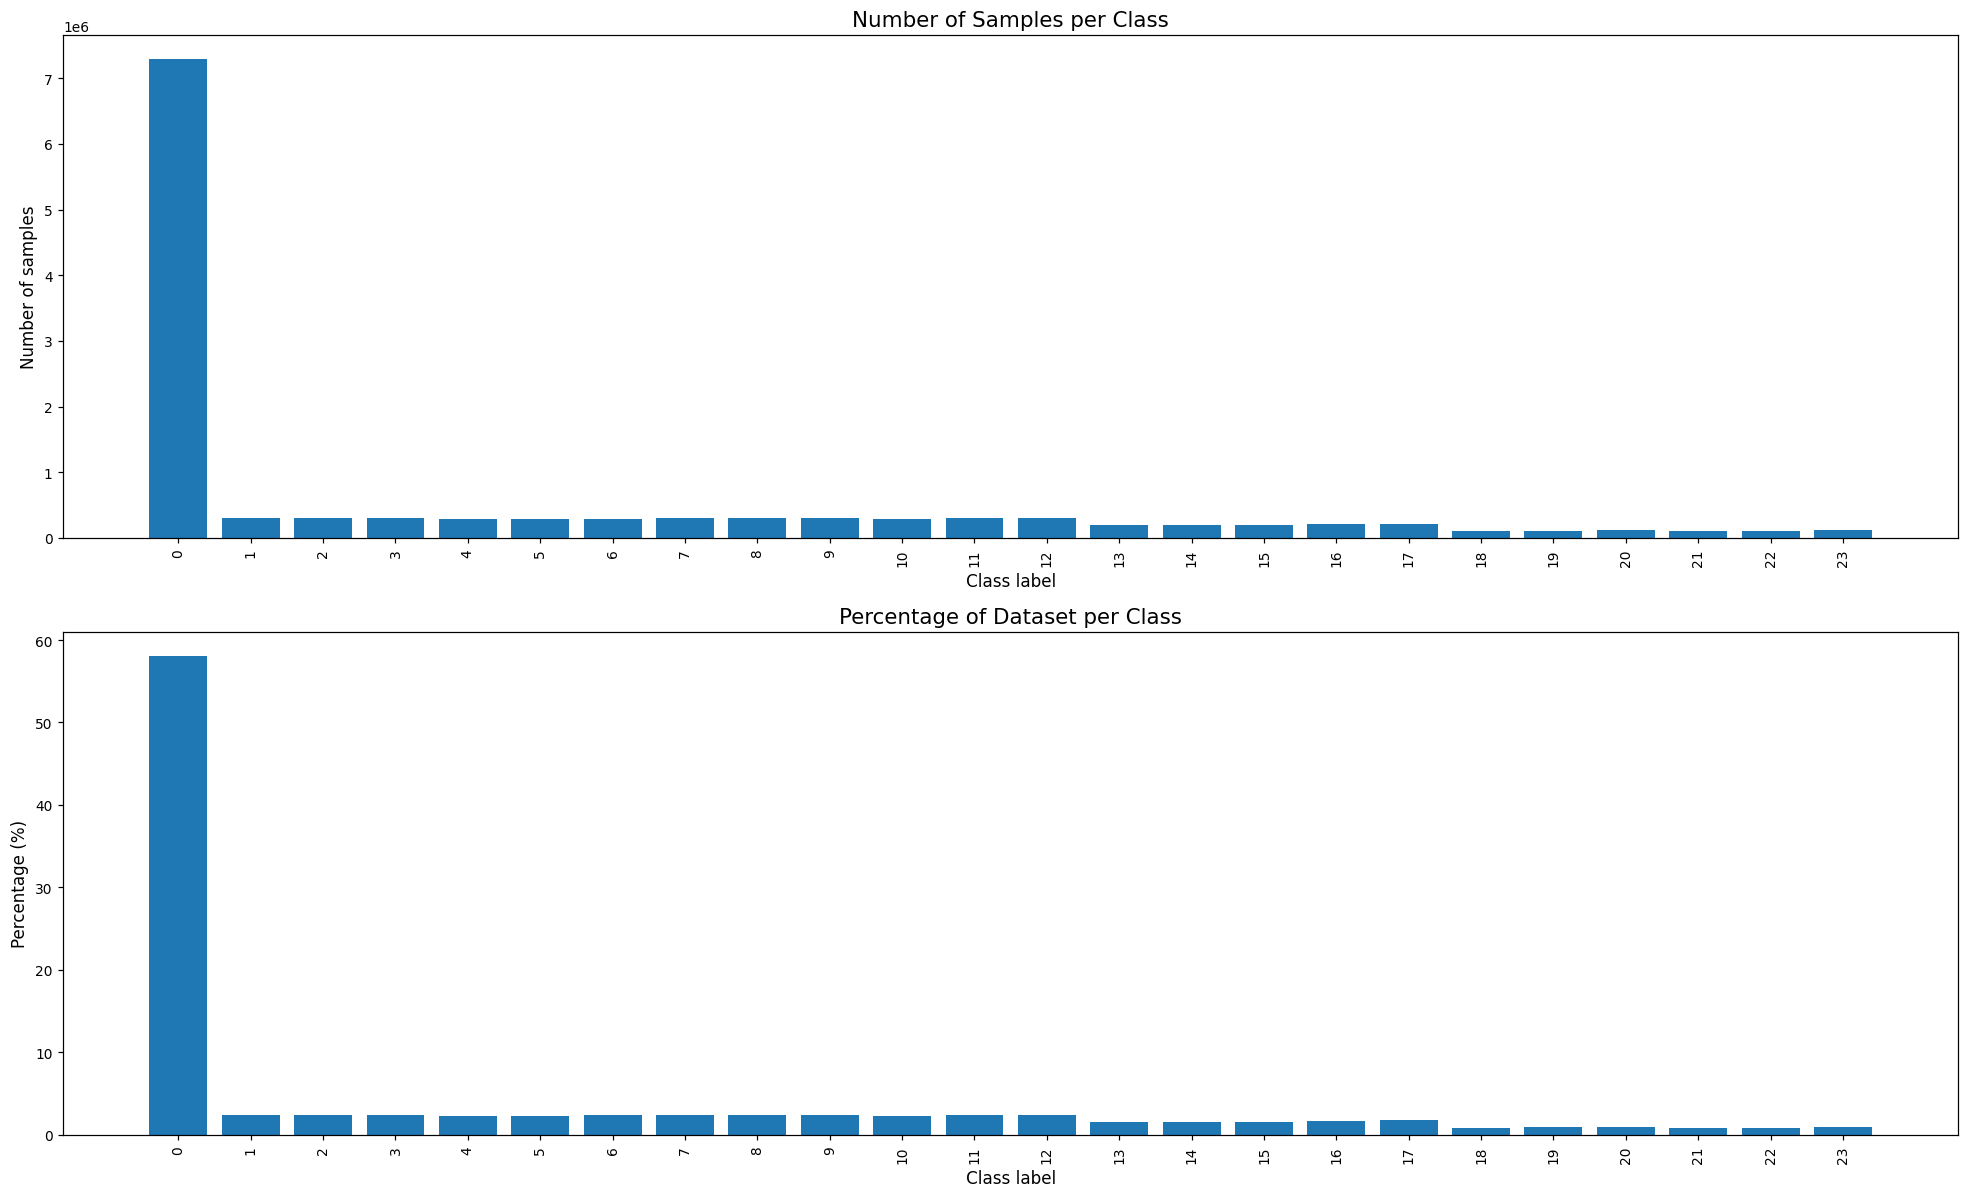

Reading: rest represents 58.08% of all samples. Among active movements, the largest-to-smallest class ratio is 2.89.
Metric implication: report macro F1 and balanced accuracy alongside accuracy when class frequencies are unequal.


In [30]:
fig, axes = plt.subplots(2, 1, figsize=(18, 11))

axes[0].bar(
    class_balance_df["Class"].astype(str),
    class_balance_df["Samples"]
)
axes[0].set_title("Number of Samples per Class")
axes[0].set_xlabel("Class label")
axes[0].set_ylabel("Number of samples")
axes[0].tick_params(axis="x", rotation=90)

axes[1].bar(
    class_balance_df["Class"].astype(str),
    class_balance_df["Percentage"]
)
axes[1].set_title("Percentage of Dataset per Class")
axes[1].set_xlabel("Class label")
axes[1].set_ylabel("Percentage (%)")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

active_balance = class_balance_df[class_balance_df["Class"] != 0]
imbalance_ratio = (
    active_balance["Samples"].max() / active_balance["Samples"].min()
    if len(active_balance) > 1 else np.nan
)
rest_percentage = float(
    class_balance_df.loc[class_balance_df["Class"] == 0, "Percentage"].sum()
)

print(
    f"Reading: rest represents {rest_percentage:.2f}% of all samples. "
    f"Among active movements, the largest-to-smallest class ratio is "
    f"{imbalance_ratio:.2f}."
)
print(
    "Metric implication: report macro F1 and balanced accuracy alongside accuracy "
    "when class frequencies are unequal."
)

# E. Feature distributions and class separation

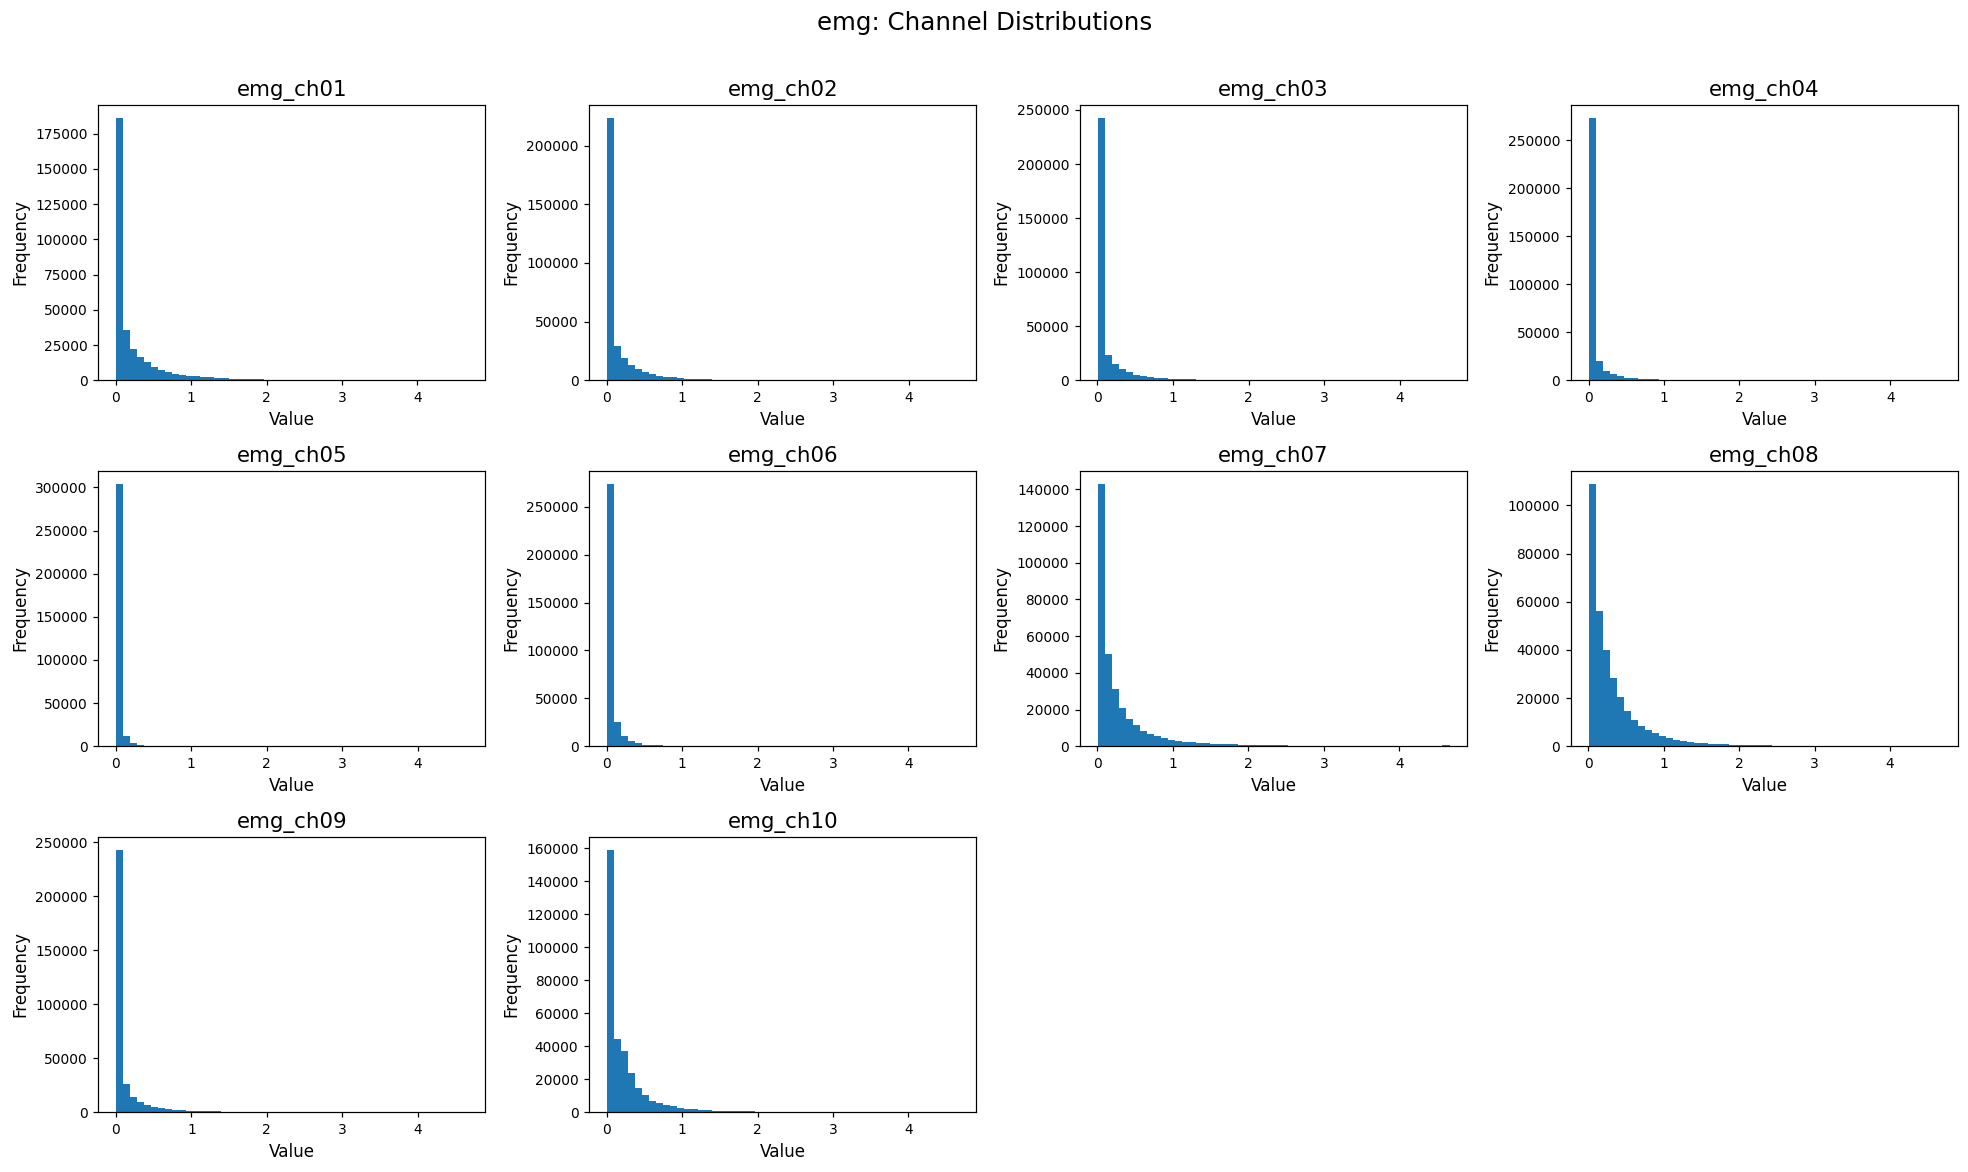

Reading for emg: median absolute channel skewness is 5.14.


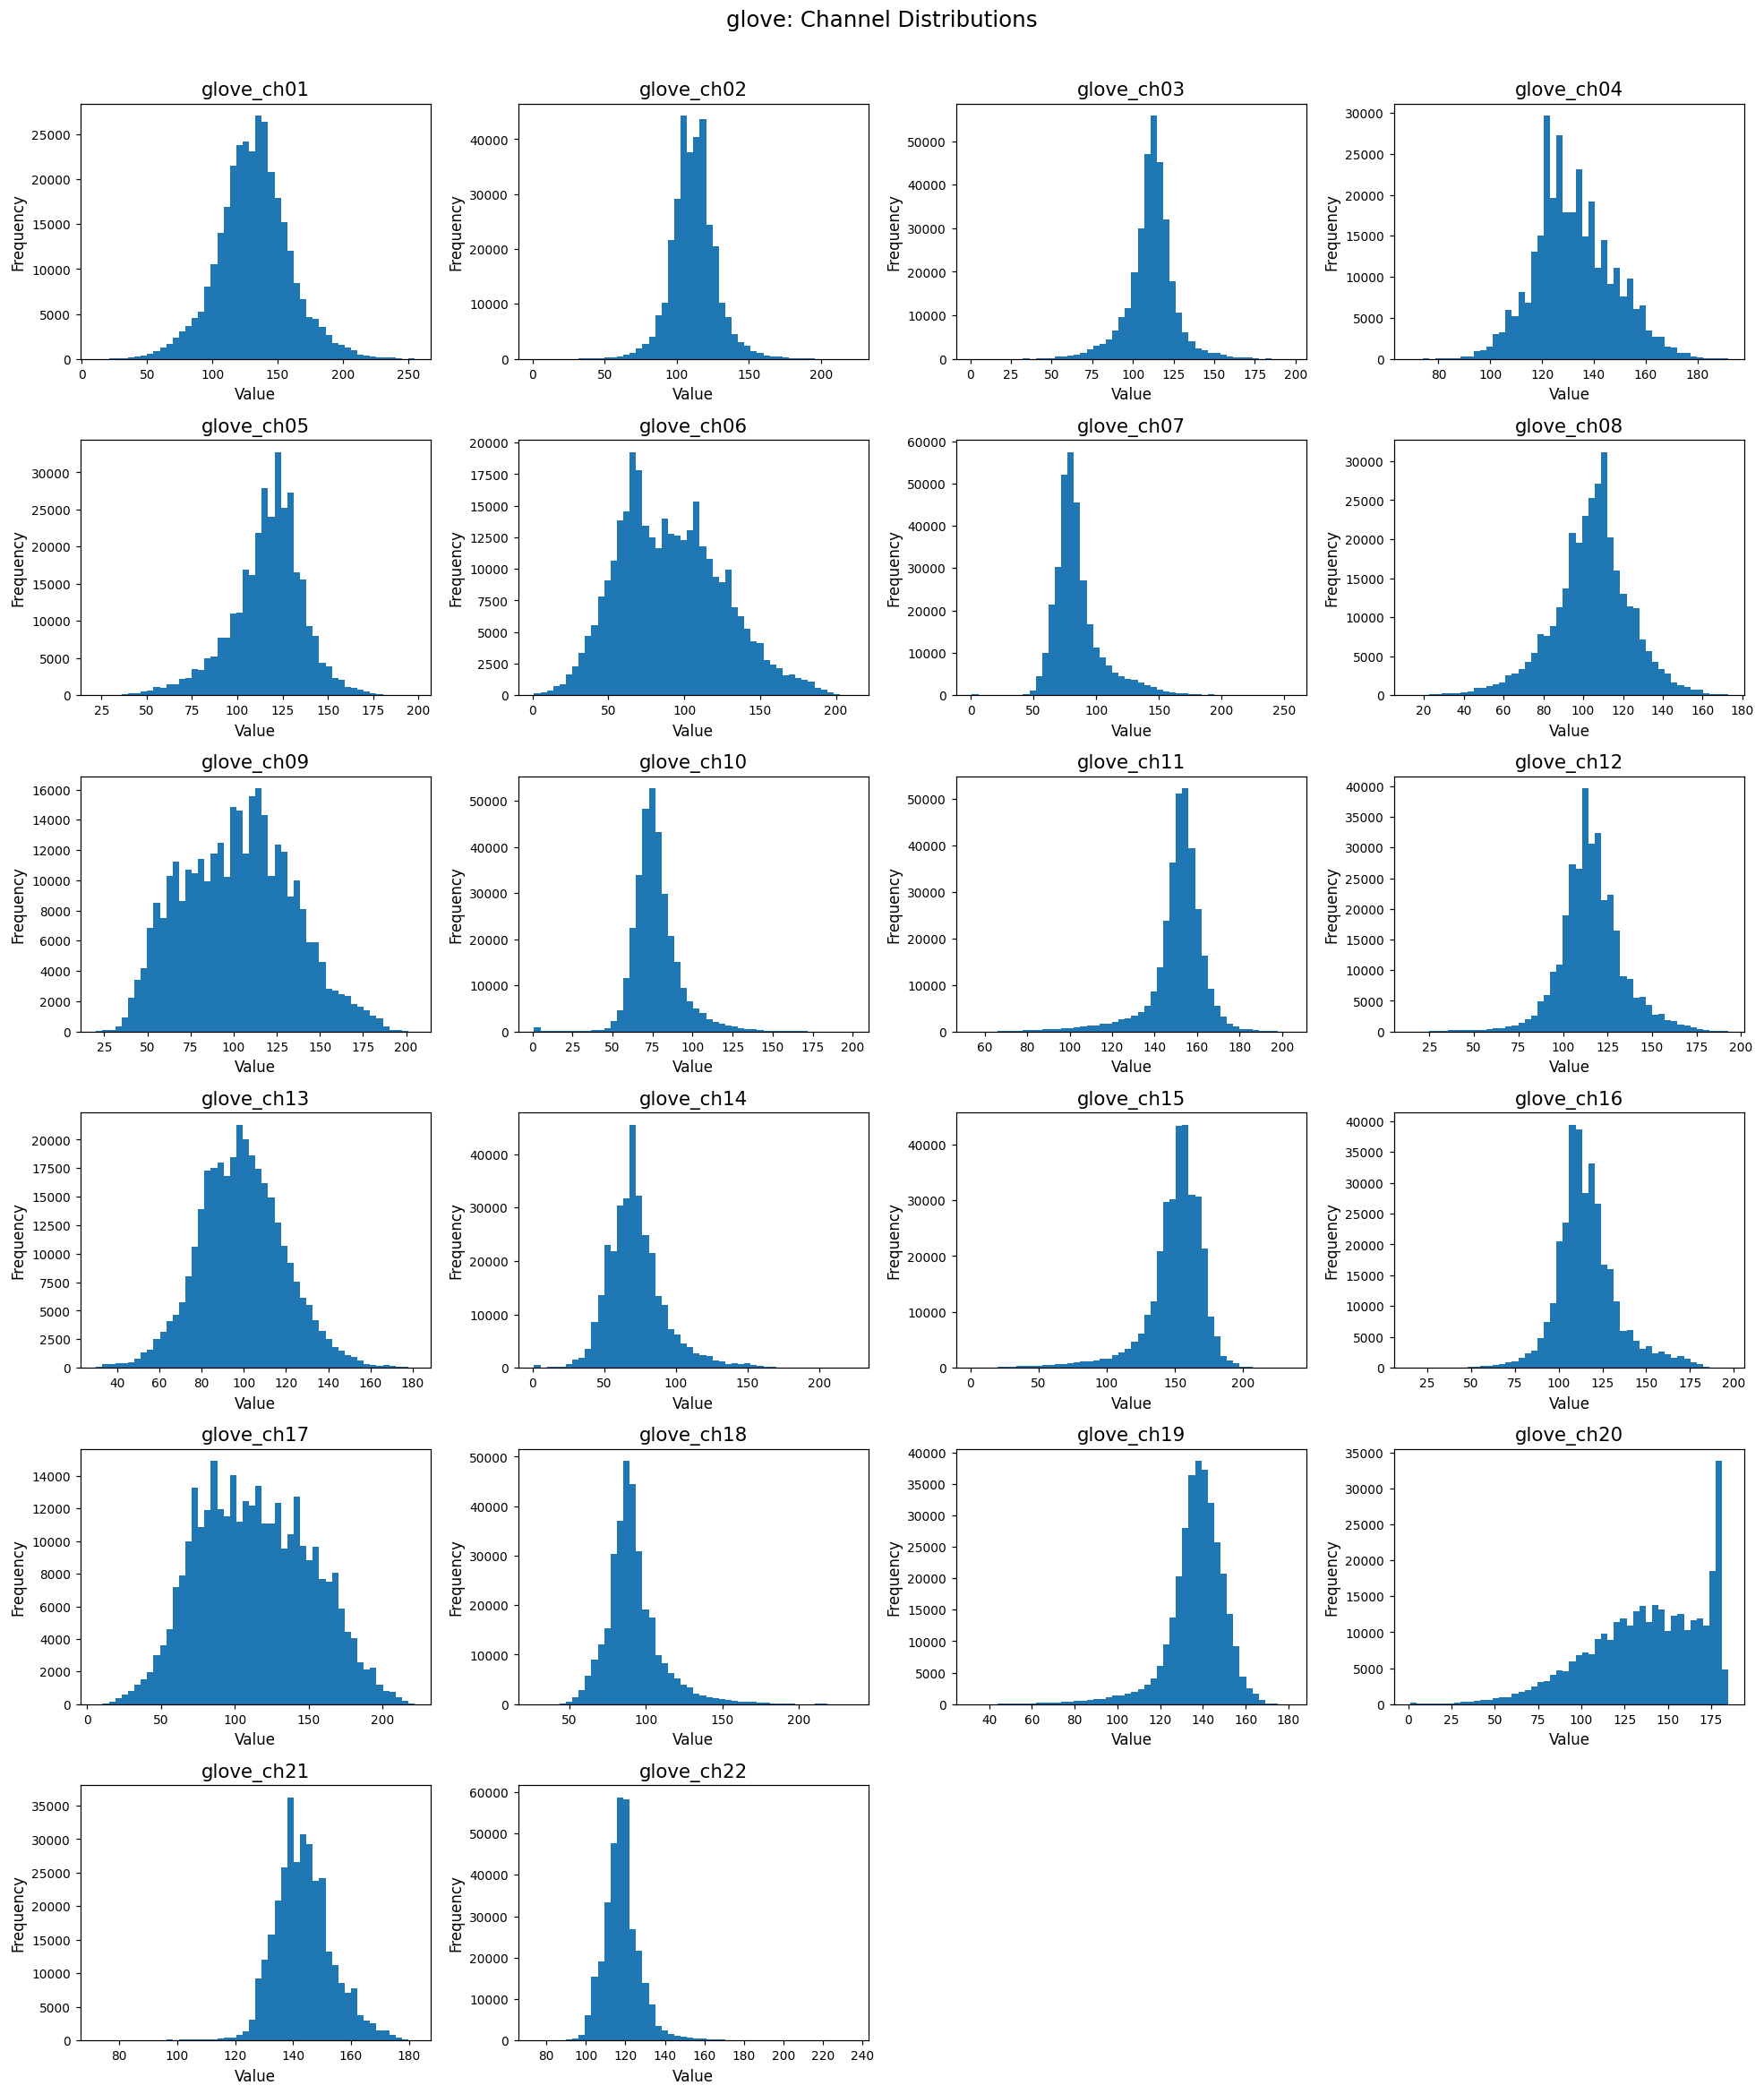

Reading for glove: median absolute channel skewness is 0.47.


In [31]:
def plot_histogram_grid(dataframe, columns, title):
    count = len(columns)
    ncols = min(4, count)
    nrows = math.ceil(count / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.5 * ncols, 3.5 * nrows),
        squeeze=False
    )

    for axis, column in zip(axes.ravel(), columns):
        axis.hist(dataframe[column].dropna(), bins=50)
        axis.set_title(column)
        axis.set_xlabel("Value")
        axis.set_ylabel("Frequency")

    for axis in axes.ravel()[count:]:
        axis.axis("off")

    fig.suptitle(title, y=1.01, fontsize=16)
    plt.tight_layout()
    plt.show()


for group_name, columns in signal_groups.items():
    plot_histogram_grid(
        sampled_df,
        columns,
        f"{group_name}: Channel Distributions"
    )

    median_abs_skew = statistics_df.loc[columns, "Skewness"].abs().median()
    print(
        f"Reading for {group_name}: median absolute channel skewness is "
        f"{median_abs_skew:.2f}."
    )

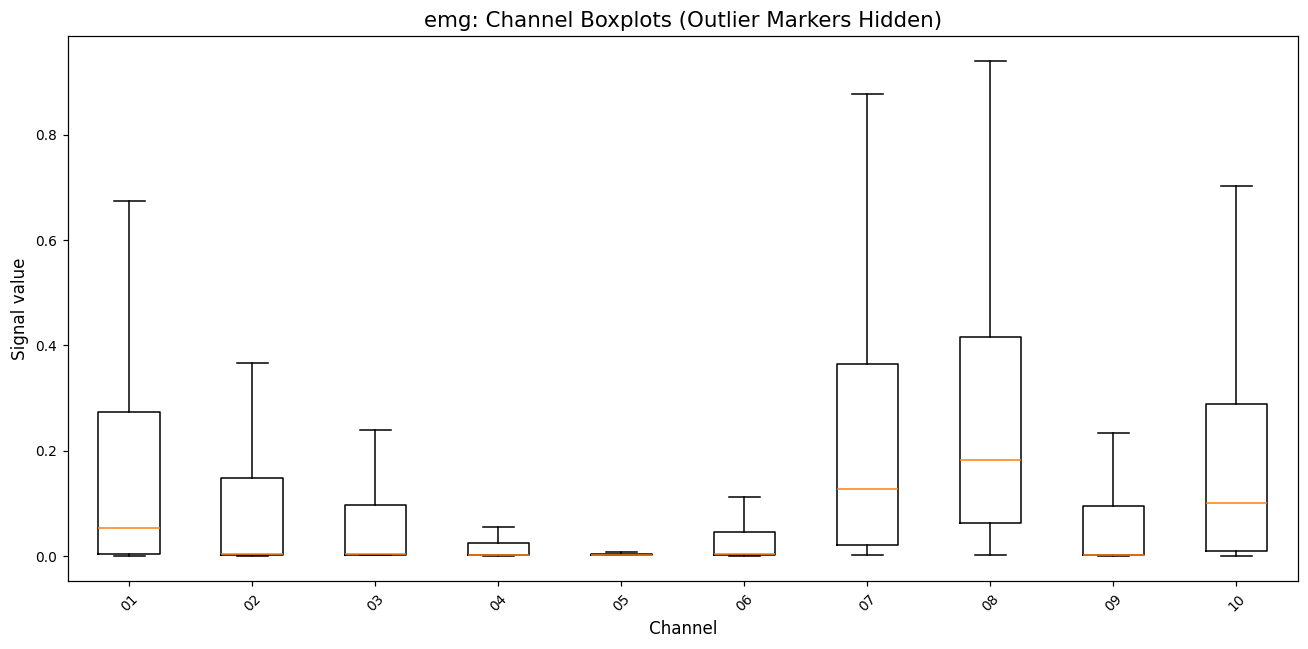

Reading for emg: emg_ch08 has the widest central spread (IQR = 0.3515).


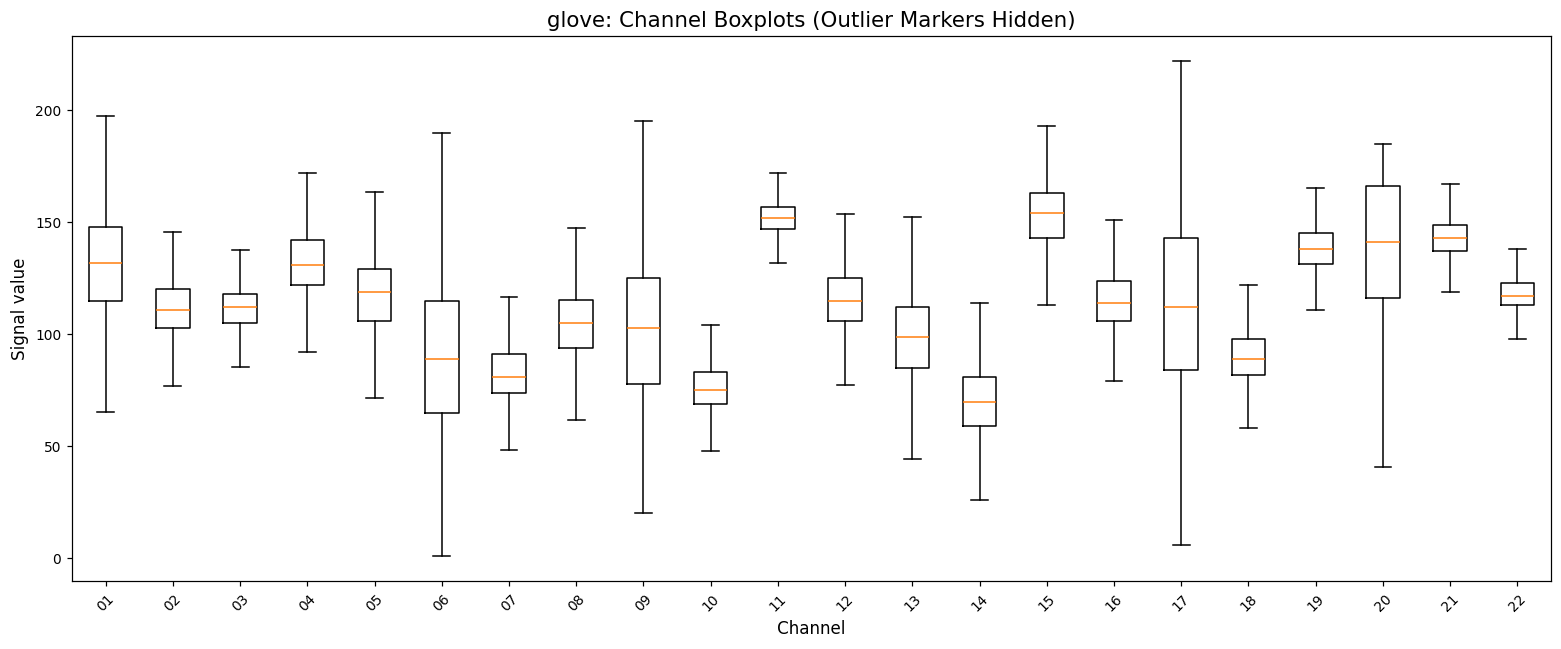

Reading for glove: glove_ch17 has the widest central spread (IQR = 58.7911).


In [32]:
for group_name, columns in signal_groups.items():
    fig, ax = plt.subplots(figsize=(max(12, 0.65 * len(columns)), 6))

    ax.boxplot(
        [sampled_df[column].dropna().values for column in columns],
        labels=[column.split("_ch")[-1] for column in columns],
        showfliers=False
    )
    ax.set_title(f"{group_name}: Channel Boxplots (Outlier Markers Hidden)")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Signal value")
    ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

    widest = statistics_df.loc[columns, "IQR"].idxmax()
    print(
        f"Reading for {group_name}: {widest} has the widest central spread "
        f"(IQR = {statistics_df.loc[widest, 'IQR']:.4f})."
    )

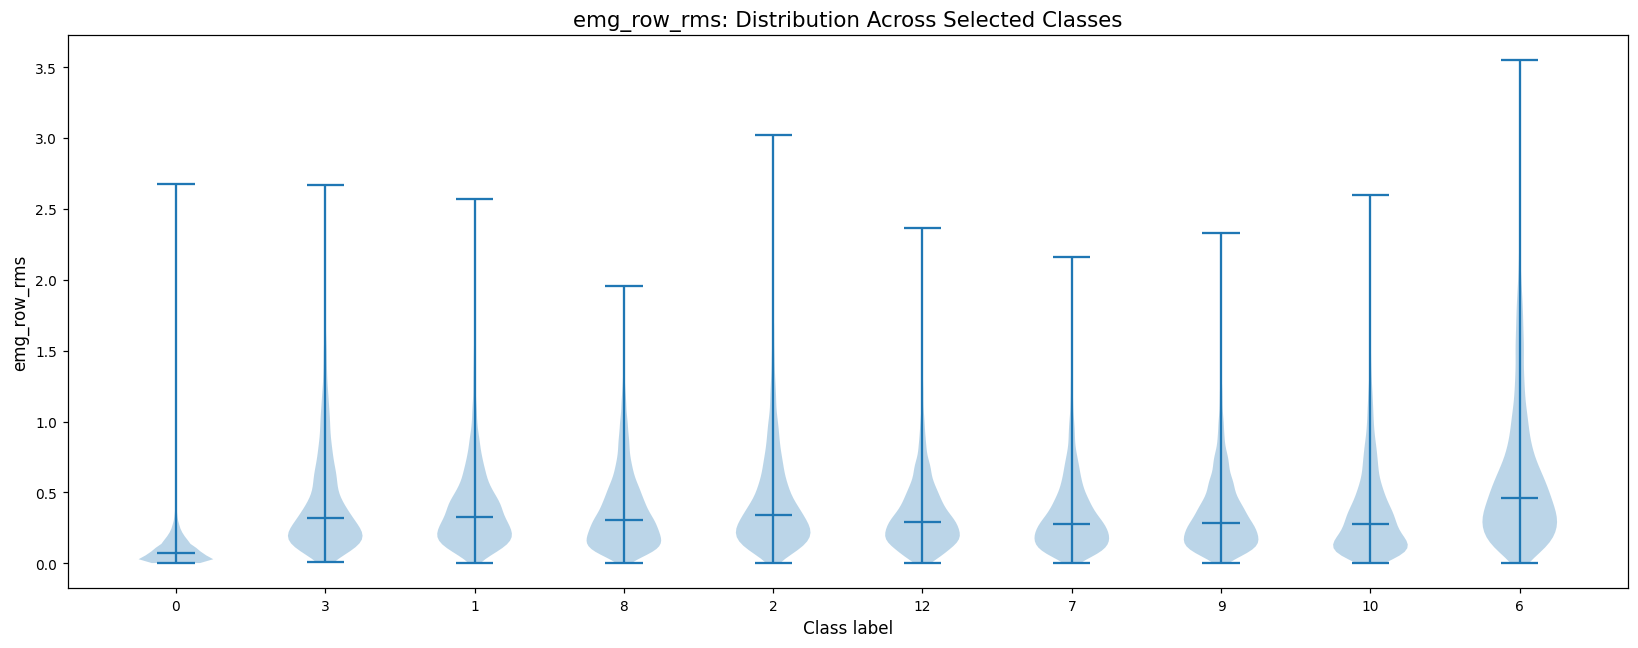

Reading: the class-median range for emg_row_rms is 0.3844. Overlapping violins indicate that this single summary feature cannot fully separate the classes.


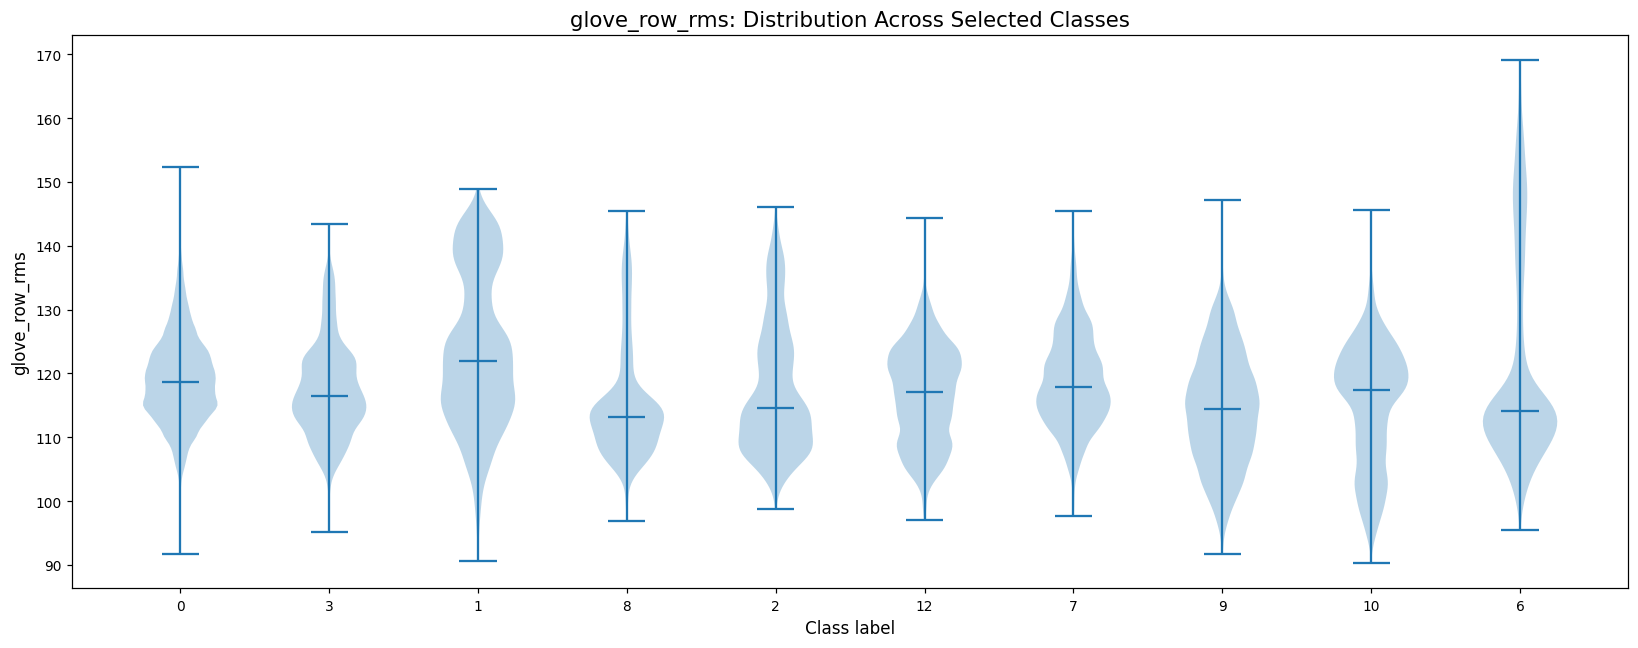

Reading: the class-median range for glove_row_rms is 8.7643. Overlapping violins indicate that this single summary feature cannot fully separate the classes.


In [33]:
summary_feature_columns = []

for group_name, columns in signal_groups.items():
    summary_name = f"{group_name}_row_rms"
    sampled_df[summary_name] = np.sqrt(
        np.nanmean(np.square(sampled_df[columns].to_numpy()), axis=1)
    )
    summary_feature_columns.append(summary_name)

active_counts_sample = (
    sampled_df.loc[sampled_df["class_label"] != 0, "class_label"]
    .value_counts()
)
selected_active_classes = active_counts_sample.head(9).index.tolist()
selected_classes = ([0] if 0 in sampled_df["class_label"].values else []) + selected_active_classes

for summary_name in summary_feature_columns:
    violin_data = [
        sampled_df.loc[
            sampled_df["class_label"] == label,
            summary_name
        ].dropna().values
        for label in selected_classes
    ]

    fig, ax = plt.subplots(figsize=(15, 6))
    ax.violinplot(
        violin_data,
        positions=np.arange(len(selected_classes)),
        showmeans=False,
        showmedians=True
    )
    ax.set_title(f"{summary_name}: Distribution Across Selected Classes")
    ax.set_xlabel("Class label")
    ax.set_ylabel(summary_name)
    ax.set_xticks(np.arange(len(selected_classes)))
    ax.set_xticklabels(selected_classes)

    plt.tight_layout()
    plt.show()

    medians = {
        label: np.median(values)
        for label, values in zip(selected_classes, violin_data)
        if len(values)
    }
    median_range = max(medians.values()) - min(medians.values())

    print(
        f"Reading: the class-median range for {summary_name} is "
        f"{median_range:.4f}. Overlapping violins indicate that this single "
        "summary feature cannot fully separate the classes."
    )

## E2. Rest versus active movement

,Feature,Activity,Mean,Median,Std
0,emg_row_rms,Movement,0.4557,0.3444,0.3829
1,emg_row_rms,Rest,0.1009,0.0758,0.0960
2,glove_row_rms,Movement,116.3734,115.4650,10.0189
3,glove_row_rms,Rest,119.0934,118.6741,6.8191


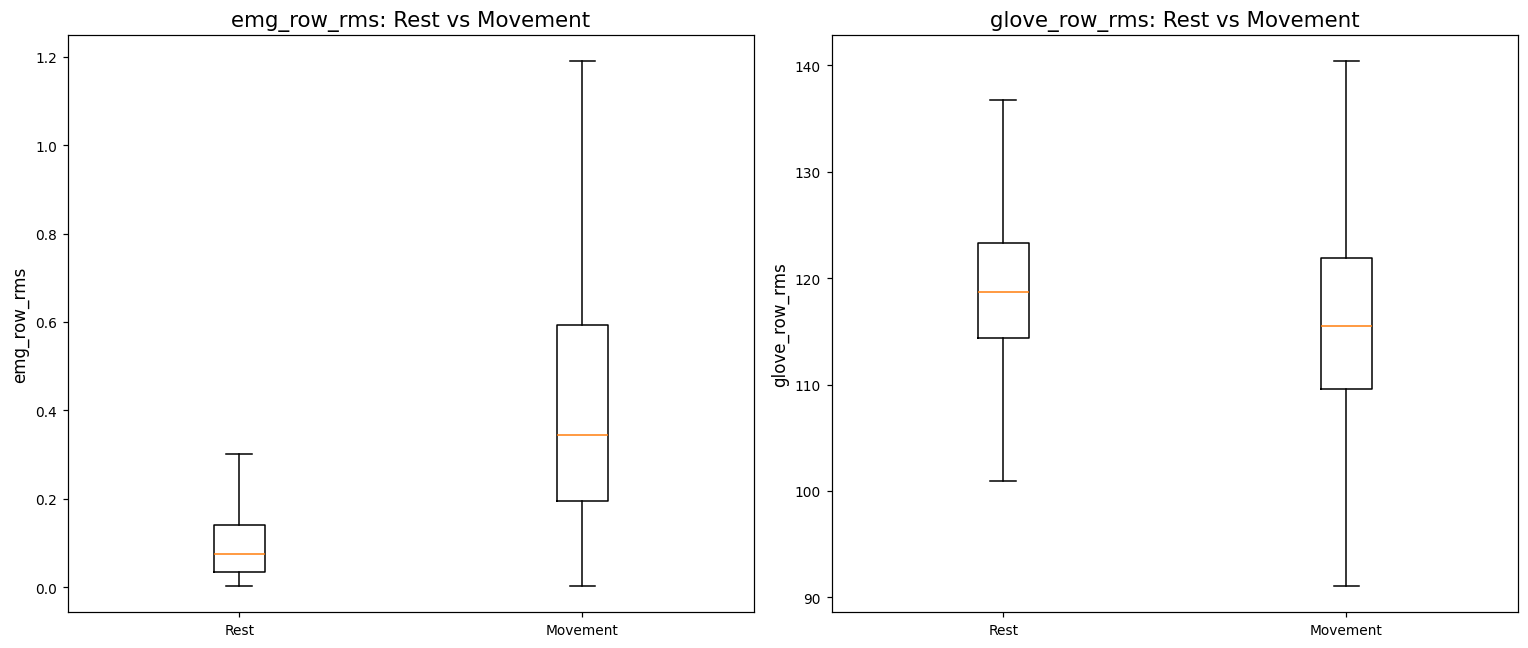

Reading: differences in medians and spread show how signal activity changes between rest and movement periods.


In [34]:
sampled_df["Activity"] = np.where(
    sampled_df["class_label"] == 0,
    "Rest",
    "Movement"
)

rest_active_rows = []

for feature in summary_feature_columns:
    grouped = sampled_df.groupby("Activity")[feature]

    for activity, values in grouped:
        rest_active_rows.append({
            "Feature": feature,
            "Activity": activity,
            "Mean": values.mean(),
            "Median": values.median(),
            "Std": values.std()
        })

rest_active_df = pd.DataFrame(rest_active_rows)
display(rest_active_df.round(4))

fig, axes = plt.subplots(
    1,
    len(summary_feature_columns),
    figsize=(7 * len(summary_feature_columns), 6),
    squeeze=False
)

for axis, feature in zip(axes.ravel(), summary_feature_columns):
    data_to_plot = [
        sampled_df.loc[sampled_df["Activity"] == activity, feature].dropna()
        for activity in ["Rest", "Movement"]
    ]

    axis.boxplot(data_to_plot, labels=["Rest", "Movement"], showfliers=False)
    axis.set_title(f"{feature}: Rest vs Movement")
    axis.set_ylabel(feature)

plt.tight_layout()
plt.show()

print(
    "Reading: differences in medians and spread show how signal activity changes "
    "between rest and movement periods."
)

# F. Correlation and redundant features

In [35]:
correlation_matrix = sampled_df[feature_columns].corr()

redundant_pairs = []

for i, first in enumerate(feature_columns):
    for second in feature_columns[i + 1:]:
        value = correlation_matrix.loc[first, second]

        if abs(value) >= 0.95:
            redundant_pairs.append({
                "Feature_1": first,
                "Feature_2": second,
                "Correlation": value
            })

redundant_features_df = pd.DataFrame(redundant_pairs)

if not redundant_features_df.empty:
    redundant_features_df = redundant_features_df.sort_values(
        "Correlation",
        key=lambda series: series.abs(),
        ascending=False
    ).reset_index(drop=True)

print("Highly correlated feature pairs (|r| ≥ 0.95):", len(redundant_features_df))
display(redundant_features_df)

Highly correlated feature pairs (|r| ≥ 0.95): 0


""


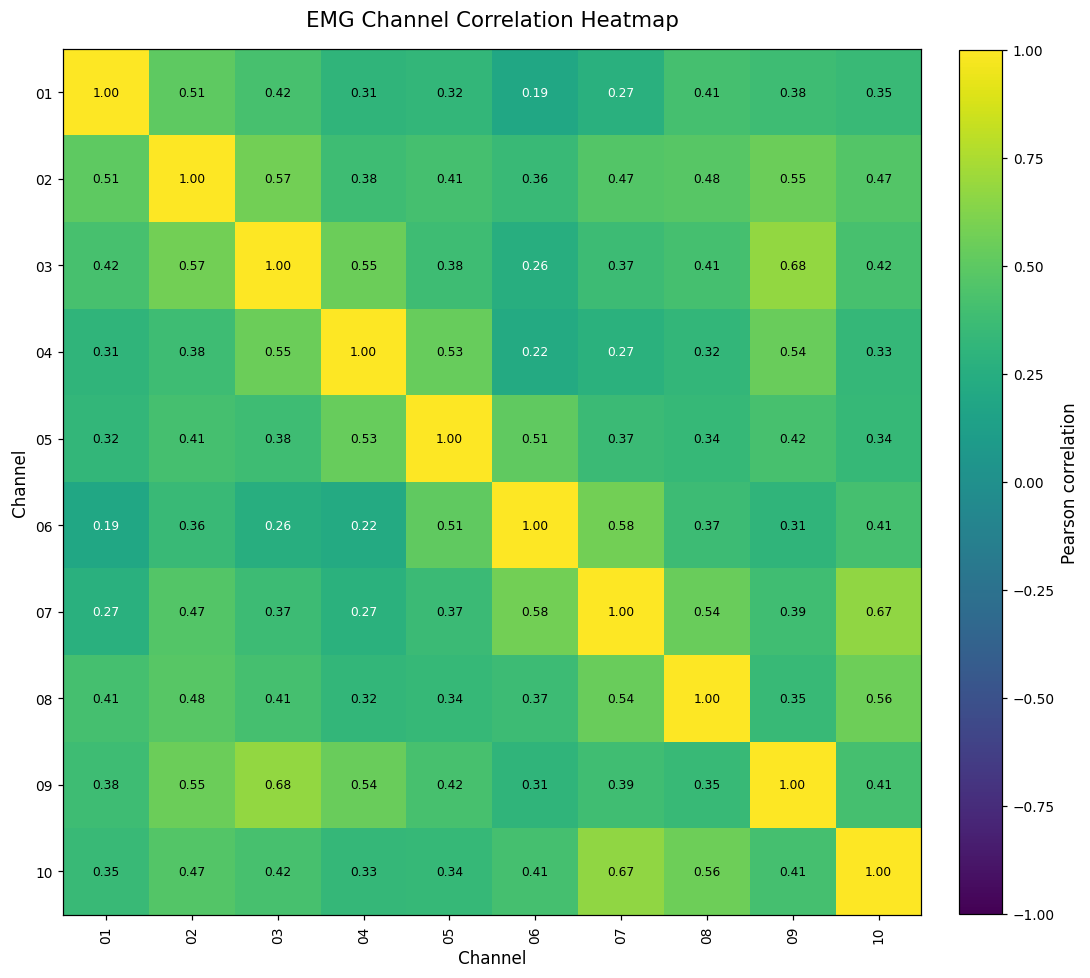

Reading for emg: the strongest channel pair is emg_ch03 and emg_ch09 (r = 0.676).


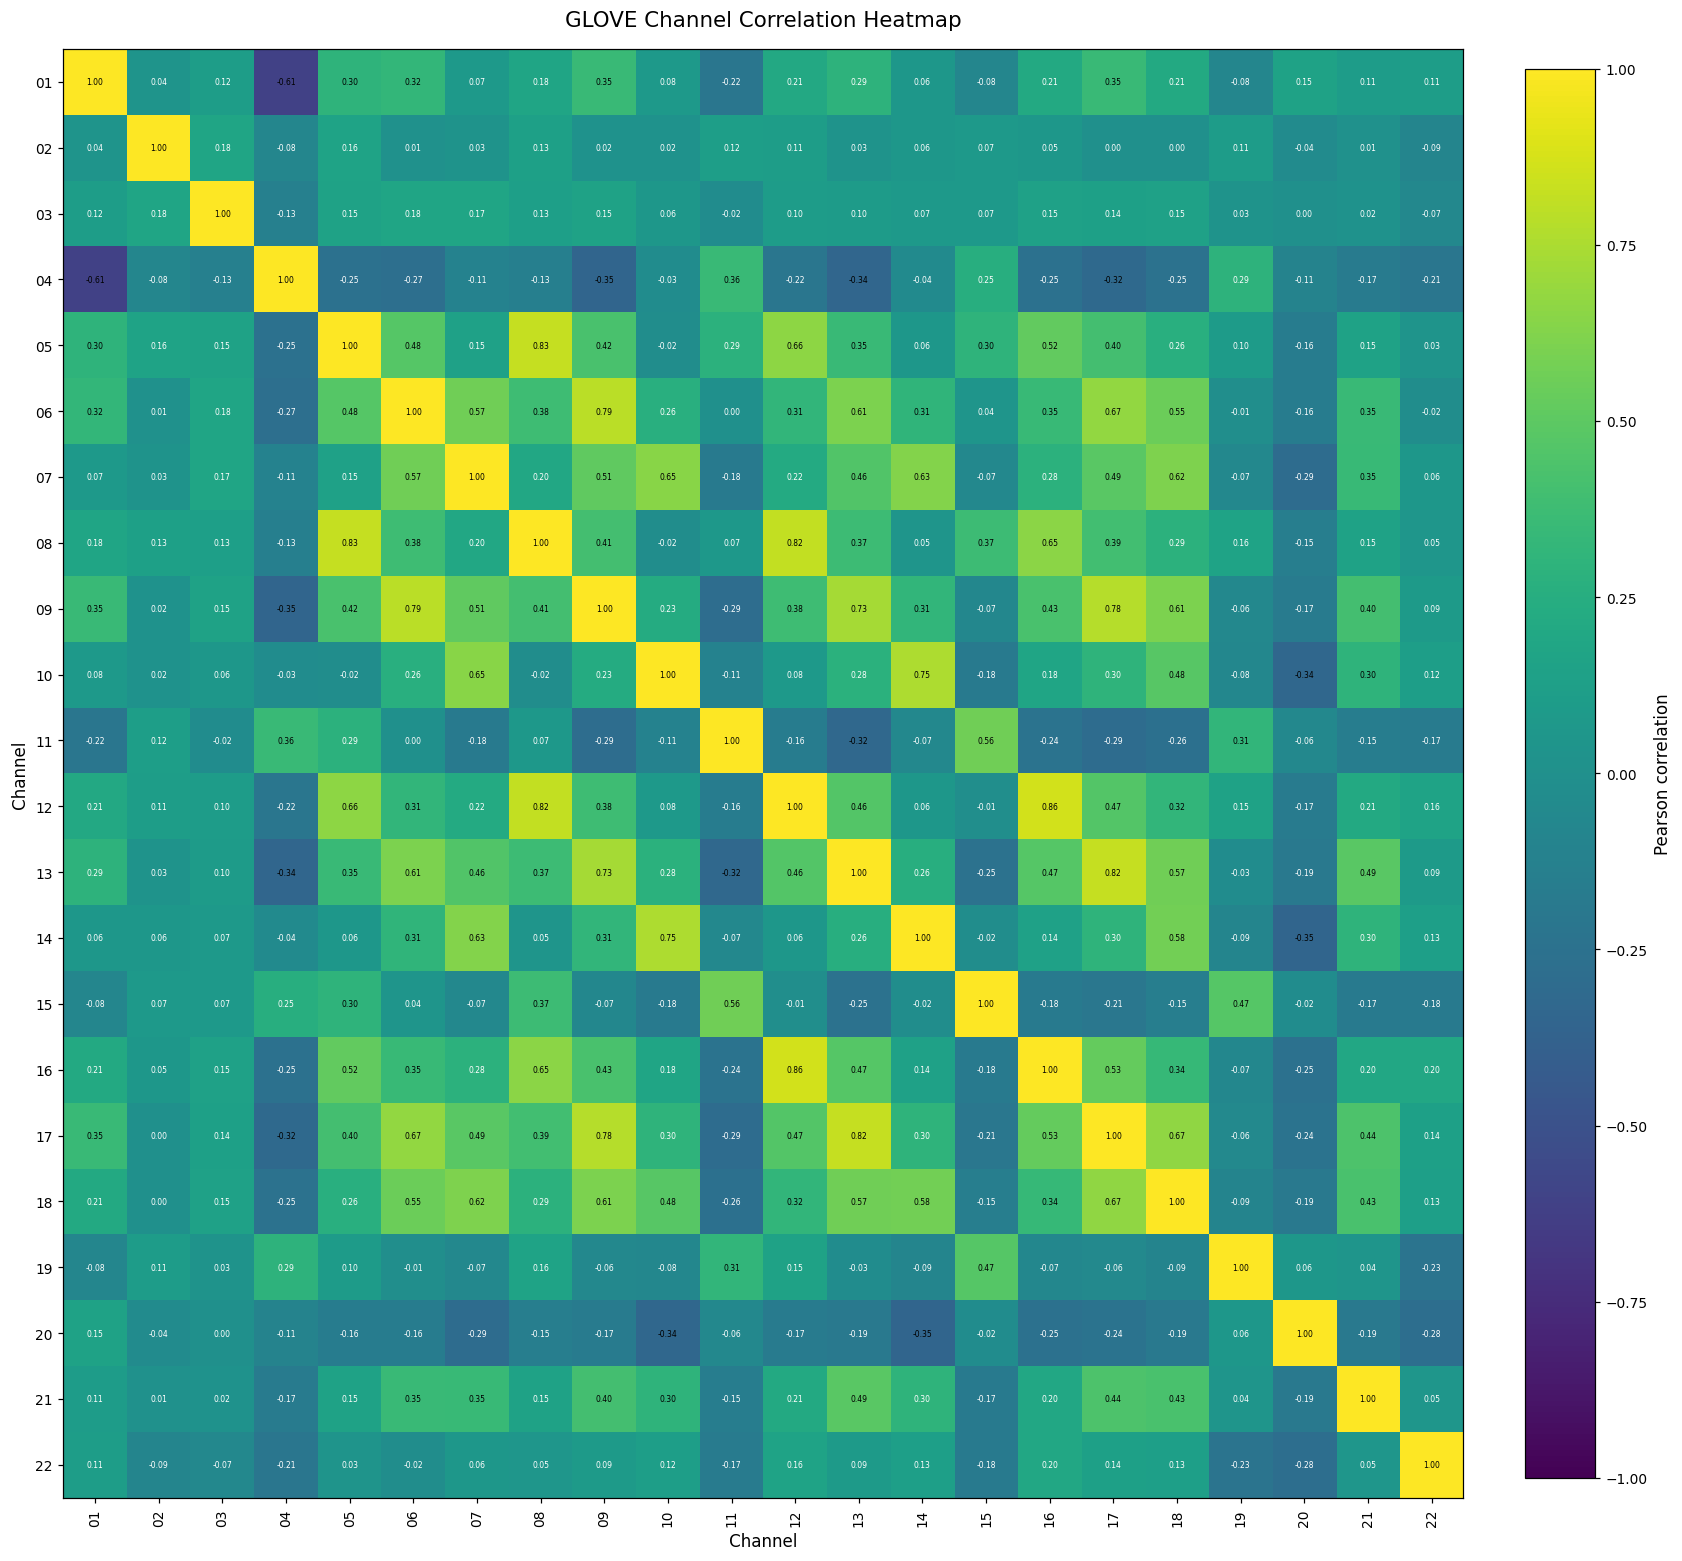

Reading for glove: the strongest channel pair is glove_ch12 and glove_ch16 (r = 0.861).


In [36]:
for group_name, columns in signal_groups.items():
    group_corr = sampled_df[columns].corr()

    number_of_channels = len(columns)

    fig, ax = plt.subplots(
        figsize=(
            max(10, 0.70 * number_of_channels),
            max(9, 0.65 * number_of_channels)
        )
    )

    image = ax.imshow(
        group_corr.values,
        vmin=-1,
        vmax=1,
        aspect="auto"
    )

    channel_labels = [
        column.split("_ch")[-1]
        for column in columns
    ]

    ax.set_title(
        f"{group_name.upper()} Channel Correlation Heatmap",
        pad=15
    )
    ax.set_xlabel("Channel")
    ax.set_ylabel("Channel")

    ax.set_xticks(np.arange(number_of_channels))
    ax.set_yticks(np.arange(number_of_channels))

    ax.set_xticklabels(
        channel_labels,
        rotation=90
    )
    ax.set_yticklabels(channel_labels)

    # Smaller text for the 22 × 22 glove heatmap
    annotation_size = (
        8 if number_of_channels <= 10 else 5
    )

    # Add correlation values inside the cells
    for row in range(number_of_channels):
        for column in range(number_of_channels):
            correlation_value = group_corr.iloc[row, column]

            # Change text colour for better visibility
            text_colour = (
                "white"
                if abs(correlation_value) < 0.30
                else "black"
            )

            ax.text(
                column,
                row,
                f"{correlation_value:.2f}",
                ha="center",
                va="center",
                fontsize=annotation_size,
                color=text_colour
            )

    fig.colorbar(
        image,
        ax=ax,
        label="Pearson correlation",
        fraction=0.046,
        pad=0.04
    )

    plt.tight_layout()
    plt.show()

    # Find the strongest correlation except the diagonal
    upper = group_corr.where(
        np.triu(
            np.ones(group_corr.shape),
            k=1
        ).astype(bool)
    ).stack()

    if len(upper):
        pair = upper.abs().idxmax()
        value = group_corr.loc[pair[0], pair[1]]

        print(
            f"Reading for {group_name}: "
            f"the strongest channel pair is "
            f"{pair[0]} and {pair[1]} "
            f"(r = {value:.3f})."
        )

## F2. Relationships between signal groups

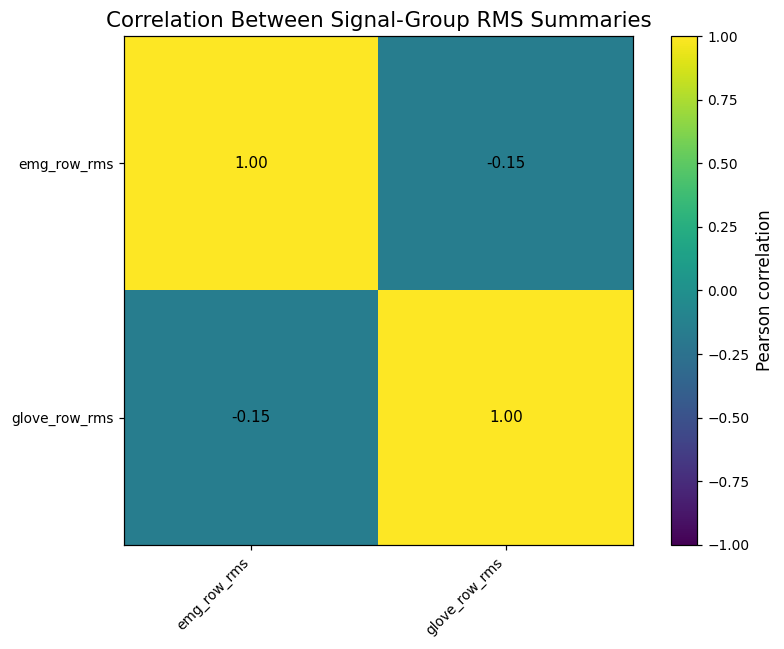

Reading: this compact heatmap shows whether overall activity in one signal group changes with overall activity in another signal group.


In [37]:
group_relationships = pd.DataFrame(index=summary_feature_columns, columns=summary_feature_columns)

for first in summary_feature_columns:
    for second in summary_feature_columns:
        group_relationships.loc[first, second] = sampled_df[[first, second]].corr().iloc[0, 1]

group_relationships = group_relationships.astype(float)

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(group_relationships.values, vmin=-1, vmax=1)

ax.set_title("Correlation Between Signal-Group RMS Summaries")
ax.set_xticks(np.arange(len(summary_feature_columns)))
ax.set_yticks(np.arange(len(summary_feature_columns)))
ax.set_xticklabels(summary_feature_columns, rotation=45, ha="right")
ax.set_yticklabels(summary_feature_columns)

for i in range(len(summary_feature_columns)):
    for j in range(len(summary_feature_columns)):
        ax.text(
            j, i,
            f"{group_relationships.iloc[i, j]:.2f}",
            ha="center", va="center"
        )

fig.colorbar(image, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

print(
    "Reading: this compact heatmap shows whether overall activity in one signal "
    "group changes with overall activity in another signal group."
)

# NinaPro-specific temporal analysis

## Synchronized signal and annotation view

In [ ]:
display_file = mat_files[0]
display_data = load_arrays(display_file)
display_layout = detect_layout(display_data)

DISPLAY_SAMPLES = min(3000, display_layout["n_samples"])
time_axis = np.arange(DISPLAY_SAMPLES) / SAMPLING_RATE_HZ

rows = len(display_layout["signals"]) + (1 if display_layout["label_key"] else 0)
fig, axes = plt.subplots(
    rows,
    1,
    figsize=(17, 4 * rows),
    sharex=True,
    squeeze=False
)

row = 0

for key in display_layout["signals"]:
    matrix = np.asarray(display_data[key])
    channels_to_show = min(10, matrix.shape[1])

    for channel in range(channels_to_show):
        axes[row, 0].plot(
            time_axis,
            matrix[:DISPLAY_SAMPLES, channel],
            label=f"Channel {channel + 1}",
            linewidth=0.9
        )

    axes[row, 0].set_title(f"{display_file.name}: {key}")
    axes[row, 0].set_ylabel("Signal value")
    axes[row, 0].legend(ncol=channels_to_show, loc="upper right")
    row += 1

if display_layout["label_key"]:
    labels = np.asarray(
        display_data[display_layout["label_key"]]
    ).reshape(-1)

    axes[row, 0].step(
        time_axis,
        labels[:DISPLAY_SAMPLES],
        where="post"
    )
    axes[row, 0].set_title(
        f"Movement Annotation: {display_layout['label_key']}"
    )
    axes[row, 0].set_ylabel("Class")

axes[-1, 0].set_xlabel("Time (seconds)")
plt.tight_layout()
plt.show()

print(
    "Reading: aligned changes in the signal panels and movement labels confirm "
    "whether the modalities and annotations behave synchronously."
)

## Repetition consistency

,Subject,Exercise,Movement,Repetition,Samples,Duration_s,emg_RMS,glove_RMS
0,1,1,3,1,524,5.24,0.1041,116.9739
1,1,1,3,2,390,3.90,0.1158,119.3290
2,1,1,3,3,481,4.81,0.0686,119.8758
3,1,1,3,4,433,4.33,0.0696,118.9301
4,1,1,3,5,460,4.60,0.0892,117.5515
5,1,1,3,6,515,5.15,0.0557,118.8589
6,1,1,3,7,199,1.99,0.0918,121.6257
7,1,1,3,8,360,3.60,0.0788,120.4541
8,1,1,3,9,424,4.24,0.0580,120.1305
9,1,1,3,10,356,3.56,0.0806,120.3775


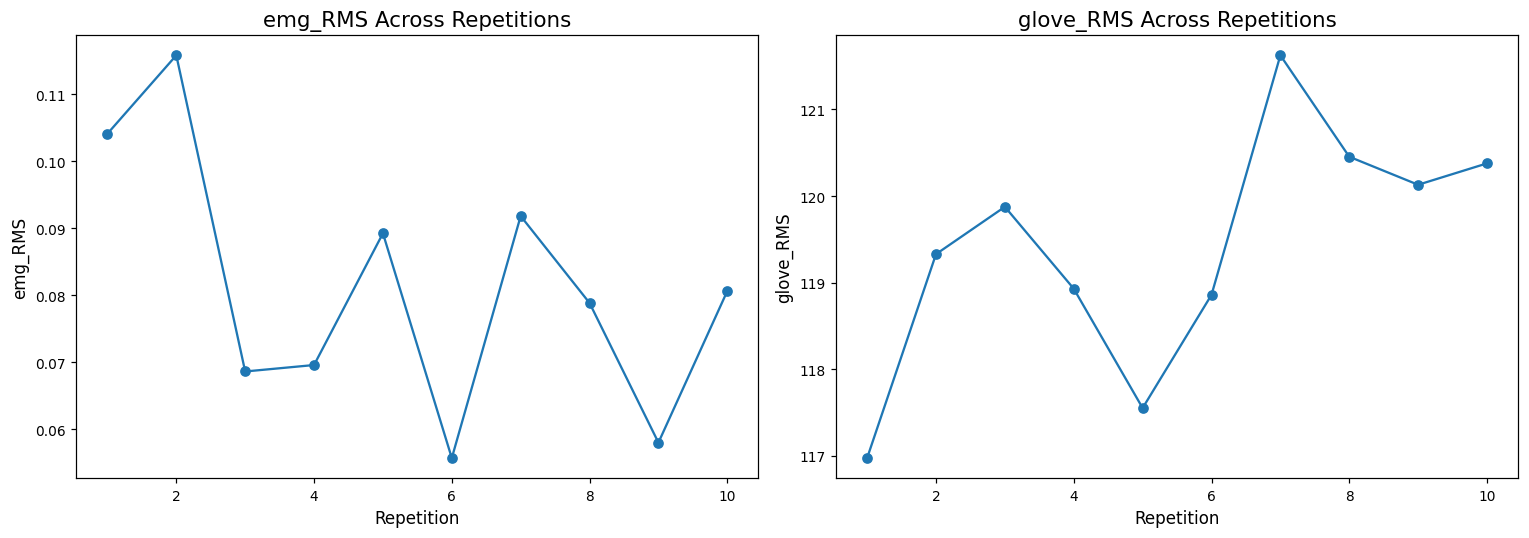

Reading: stable values across repetitions indicate repeatable recordings; large changes suggest trial variability that should be considered in data splitting.


In [30]:
repetition_file = next(
    (
        path for path in mat_files
        if detect_layout(load_arrays(path))["repetition_key"] is not None
    ),
    mat_files[0]
)

rep_data = load_arrays(repetition_file)
rep_layout = detect_layout(rep_data)
rep_ids = parse_file_ids(repetition_file)

rep_labels = np.asarray(rep_data[rep_layout["label_key"]]).reshape(-1).astype(int)
rep_numbers = np.asarray(rep_data[rep_layout["repetition_key"]]).reshape(-1).astype(int)

active_values, active_counts = np.unique(
    rep_labels[rep_labels != 0],
    return_counts=True
)
selected_movement = int(active_values[np.argmax(active_counts)])

repetition_summary = []

for repetition in sorted(np.unique(rep_numbers[rep_labels == selected_movement])):
    if repetition == 0:
        continue

    mask = (
        (rep_labels == selected_movement)
        & (rep_numbers == repetition)
    )

    row = {
        "Subject": rep_ids["subject_id"],
        "Exercise": rep_ids["exercise_id"],
        "Movement": selected_movement,
        "Repetition": repetition,
        "Samples": int(mask.sum()),
        "Duration_s": mask.sum() / SAMPLING_RATE_HZ
    }

    for key in rep_layout["signals"]:
        matrix = np.asarray(rep_data[key])
        row[f"{key}_RMS"] = float(
            np.sqrt(np.mean(np.square(matrix[mask])))
        )

    repetition_summary.append(row)

repetition_summary_df = pd.DataFrame(repetition_summary)
display(repetition_summary_df.round(4))

numeric_columns = [
    column for column in repetition_summary_df.columns
    if column.endswith("_RMS")
]

fig, axes = plt.subplots(
    1,
    max(1, len(numeric_columns)),
    figsize=(7 * max(1, len(numeric_columns)), 5),
    squeeze=False
)

for axis, column in zip(axes.ravel(), numeric_columns):
    axis.plot(
        repetition_summary_df["Repetition"],
        repetition_summary_df[column],
        marker="o"
    )
    axis.set_title(f"{column} Across Repetitions")
    axis.set_xlabel("Repetition")
    axis.set_ylabel(column)

plt.tight_layout()
plt.show()

print(
    "Reading: stable values across repetitions indicate repeatable recordings; "
    "large changes suggest trial variability that should be considered in data splitting."
)

## Between-subject variability

,Subject,emg_row_rms_median,emg_row_rms_IQR,glove_row_rms_median,glove_row_rms_IQR
0,1,0.2272,0.3445,114.2910,12.0984
1,2,0.4525,0.4352,117.7526,14.5867
2,3,0.2433,0.2890,114.6685,12.6827
3,4,0.2166,0.2332,113.4563,11.2400
4,5,0.3299,0.3579,114.0210,16.6428
5,6,0.4365,0.5230,117.1082,13.0682
6,7,0.3627,0.2910,117.2615,13.3738
7,8,0.2338,0.2860,117.8545,11.0642
8,9,0.2367,0.3387,117.9609,9.7634
9,10,0.3059,0.3855,115.3659,10.3327


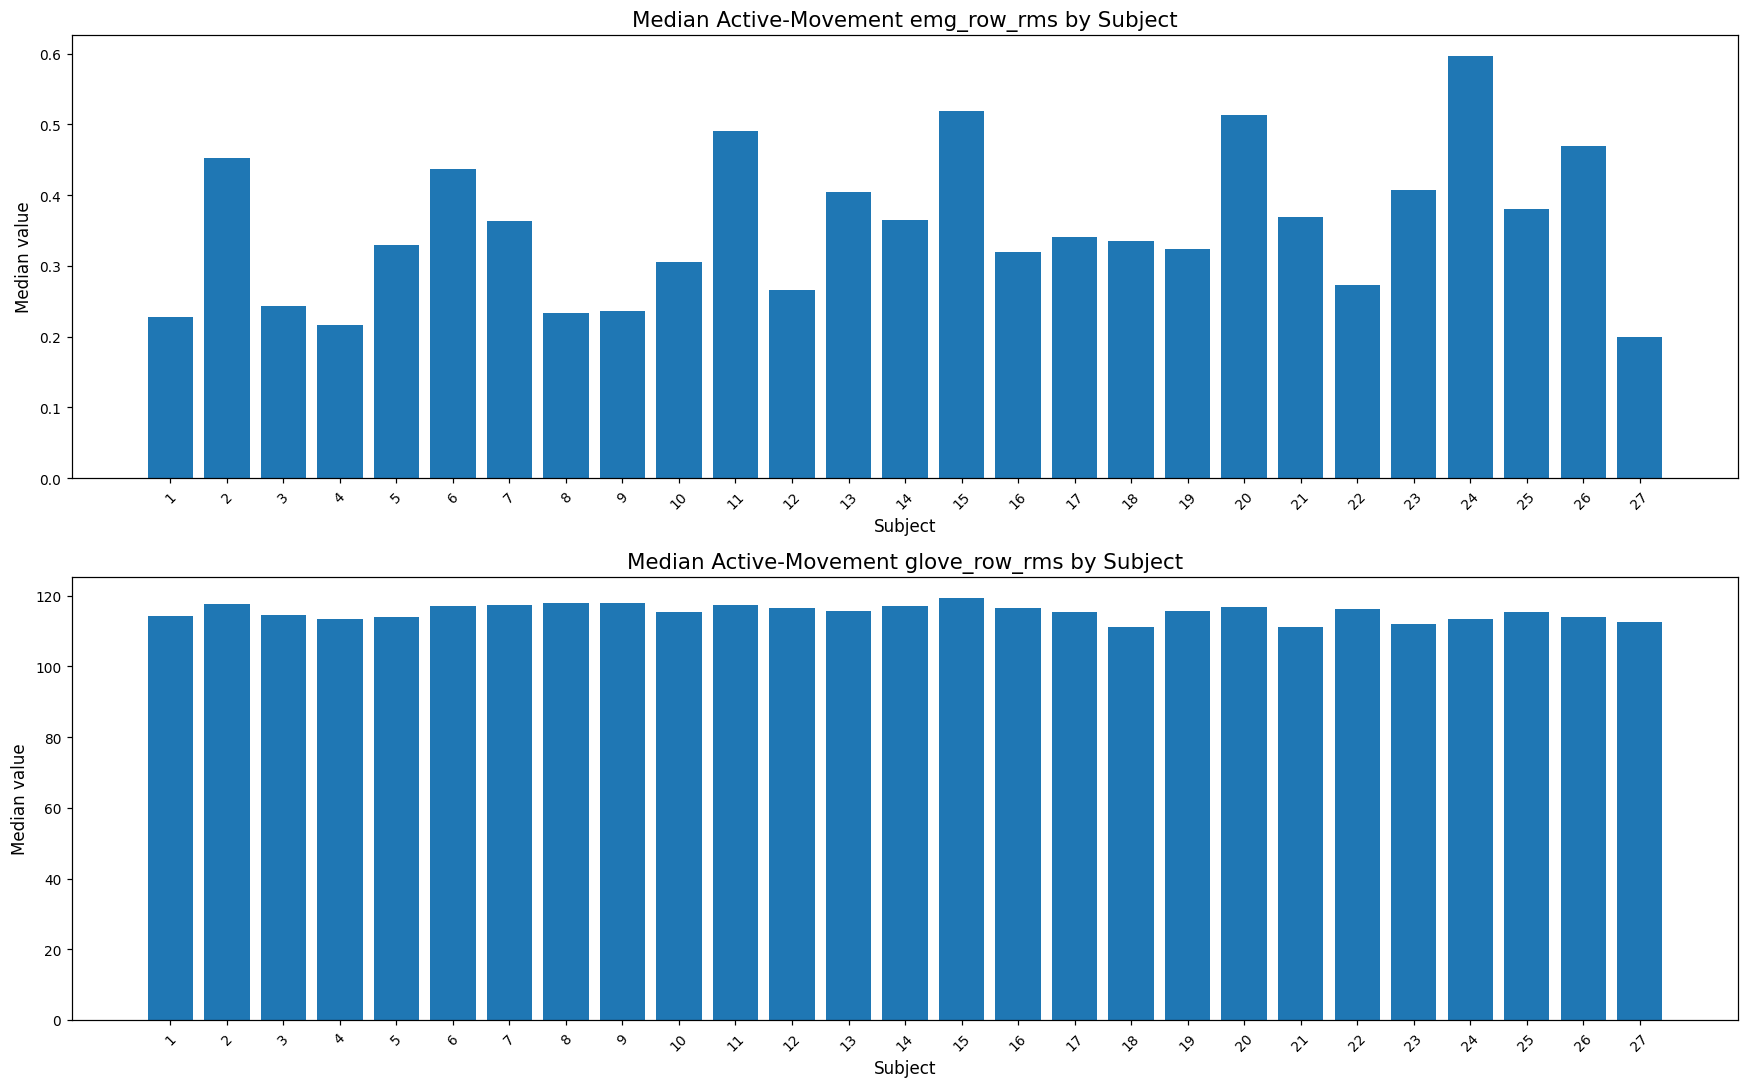

Reading: strong differences between subjects indicate that subject identity may influence the signal distribution and make cross-subject generalization harder.


In [31]:
subject_variability_rows = []

for subject, group in sampled_df.groupby("subject_id"):
    row = {"Subject": subject}

    for feature in summary_feature_columns:
        movement_values = group.loc[group["class_label"] != 0, feature]
        row[f"{feature}_median"] = movement_values.median()
        row[f"{feature}_IQR"] = (
            movement_values.quantile(0.75)
            - movement_values.quantile(0.25)
        )

    subject_variability_rows.append(row)

subject_variability_df = pd.DataFrame(subject_variability_rows)
display(subject_variability_df.round(4))

fig, axes = plt.subplots(
    len(summary_feature_columns),
    1,
    figsize=(16, 5 * len(summary_feature_columns)),
    squeeze=False
)

for axis, feature in zip(axes.ravel(), summary_feature_columns):
    median_column = f"{feature}_median"

    axis.bar(
        subject_variability_df["Subject"].astype(str),
        subject_variability_df[median_column]
    )
    axis.set_title(f"Median Active-Movement {feature} by Subject")
    axis.set_xlabel("Subject")
    axis.set_ylabel("Median value")
    axis.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(
    "Reading: strong differences between subjects indicate that subject identity "
    "may influence the signal distribution and make cross-subject generalization harder."
)

# G. PCA, t-SNE, and UMAP

Short windows are converted to descriptive signal features. A limited number of windows is retained from each file and class so that the visualizations remain computationally manageable and are not dominated by rest.

In [32]:
WINDOW_SAMPLES = 20
WINDOW_STEP = 10
CANDIDATE_WINDOWS_PER_FILE = 800
MAX_WINDOWS_PER_CLASS_PER_FILE = 20
MIN_LABEL_PURITY = 0.80

window_records = []

for file_position, file_path in enumerate(mat_files, start=1):
    data = load_arrays(file_path)
    layout = detect_layout(data)
    ids = parse_file_ids(file_path)

    if layout["label_key"] is None:
        continue

    labels = np.asarray(data[layout["label_key"]]).reshape(-1).astype(int)
    repetitions = (
        np.asarray(data[layout["repetition_key"]]).reshape(-1).astype(int)
        if layout["repetition_key"] is not None
        else np.full(layout["n_samples"], -1)
    )

    valid_starts = np.arange(
        0,
        layout["n_samples"] - WINDOW_SAMPLES + 1,
        WINDOW_STEP
    )

    if len(valid_starts) > CANDIDATE_WINDOWS_PER_FILE:
        valid_starts = rng.choice(
            valid_starts,
            size=CANDIDATE_WINDOWS_PER_FILE,
            replace=False
        )

    retained_per_class = Counter()

    for start in np.sort(valid_starts):
        end = start + WINDOW_SAMPLES
        label_segment = labels[start:end]

        label = int(mode_value(label_segment))
        purity = float(np.mean(label_segment == label))

        if purity < MIN_LABEL_PURITY:
            continue

        if retained_per_class[label] >= MAX_WINDOWS_PER_CLASS_PER_FILE:
            continue

        record = {
            "subject_id": ids["subject_id"],
            "exercise_id": ids["exercise_id"],
            "class_label": label,
            "repetition": int(mode_value(repetitions[start:end])),
            "file": file_path.name
        }

        for key in layout["signals"]:
            window = np.asarray(data[key])[start:end]

            for channel in range(window.shape[1]):
                values = window[:, channel]
                prefix = f"{key}_ch{channel + 1:02d}"

                record[f"{prefix}_mean"] = float(np.mean(values))
                record[f"{prefix}_std"] = float(np.std(values))
                record[f"{prefix}_rms"] = float(
                    np.sqrt(np.mean(np.square(values)))
                )
                record[f"{prefix}_madiff"] = float(
                    np.mean(np.abs(np.diff(values)))
                )

        window_records.append(record)
        retained_per_class[label] += 1

    if file_position % 10 == 0 or file_position == len(mat_files):
        print(f"Window features: processed {file_position}/{len(mat_files)} files")

window_df = pd.DataFrame(window_records)

window_metadata = {
    "subject_id", "exercise_id", "class_label",
    "repetition", "file"
}
window_feature_columns = [
    column for column in window_df.columns
    if column not in window_metadata
]

print("Window records:", f"{len(window_df):,}")
print("Window features:", len(window_feature_columns))
display(window_df.head())

Window features: processed 10/81 files
Window features: processed 20/81 files
Window features: processed 30/81 files
Window features: processed 40/81 files
Window features: processed 50/81 files
Window features: processed 60/81 files
Window features: processed 70/81 files
Window features: processed 80/81 files
Window features: processed 81/81 files
Window records: 24,571
Window features: 128


,subject_id,exercise_id,class_label,repetition,file,emg_ch01_mean,emg_ch01_std,emg_ch01_rms,emg_ch01_madiff,emg_ch02_mean,emg_ch02_std,emg_ch02_rms,emg_ch02_madiff,emg_ch03_mean,emg_ch03_std,emg_ch03_rms,emg_ch03_madiff,emg_ch04_mean,emg_ch04_std,emg_ch04_rms,emg_ch04_madiff,emg_ch05_mean,emg_ch05_std,emg_ch05_rms,emg_ch05_madiff,emg_ch06_mean,emg_ch06_std,emg_ch06_rms,emg_ch06_madiff,emg_ch07_mean,emg_ch07_std,emg_ch07_rms,emg_ch07_madiff,emg_ch08_mean,emg_ch08_std,emg_ch08_rms,emg_ch08_madiff,emg_ch09_mean,emg_ch09_std,emg_ch09_rms,emg_ch09_madiff,emg_ch10_mean,emg_ch10_std,emg_ch10_rms,emg_ch10_madiff,glove_ch01_mean,glove_ch01_std,glove_ch01_rms,glove_ch01_madiff,glove_ch02_mean,glove_ch02_std,glove_ch02_rms,glove_ch02_madiff,glove_ch03_mean,glove_ch03_std,glove_ch03_rms,glove_ch03_madiff,glove_ch04_mean,glove_ch04_std,glove_ch04_rms,glove_ch04_madiff,glove_ch05_mean,glove_ch05_std,glove_ch05_rms,glove_ch05_madiff,glove_ch06_mean,glove_ch06_std,glove_ch06_rms,glove_ch06_madiff,glove_ch07_mean,glove_ch07_std,glove_ch07_rms,glove_ch07_madiff,glove_ch08_mean,glove_ch08_std,glove_ch08_rms,glove_ch08_madiff,glove_ch09_mean,glove_ch09_std,glove_ch09_rms,glove_ch09_madiff,glove_ch10_mean,glove_ch10_std,glove_ch10_rms,glove_ch10_madiff,glove_ch11_mean,glove_ch11_std,glove_ch11_rms,glove_ch11_madiff,glove_ch12_mean,glove_ch12_std,glove_ch12_rms,glove_ch12_madiff,glove_ch13_mean,glove_ch13_std,glove_ch13_rms,glove_ch13_madiff,glove_ch14_mean,glove_ch14_std,glove_ch14_rms,glove_ch14_madiff,glove_ch15_mean,glove_ch15_std,glove_ch15_rms,glove_ch15_madiff,glove_ch16_mean,glove_ch16_std,glove_ch16_rms,glove_ch16_madiff,glove_ch17_mean,glove_ch17_std,glove_ch17_rms,glove_ch17_madiff,glove_ch18_mean,glove_ch18_std,glove_ch18_rms,glove_ch18_madiff,glove_ch19_mean,glove_ch19_std,glove_ch19_rms,glove_ch19_madiff,glove_ch20_mean,glove_ch20_std,glove_ch20_rms,glove_ch20_madiff,glove_ch21_mean,glove_ch21_std,glove_ch21_rms,glove_ch21_madiff,glove_ch22_mean,glove_ch22_std,glove_ch22_rms,glove_ch22_madiff
0,1,1,0,0,S1_A1_E1.mat,0.036495,0.009890,0.037811,0.006042,0.0024,0.0,0.0024,0.0,0.002525,0.000545,0.002583,0.000263,0.002400,0.000000,0.002400,0.000000,0.00265,0.00075,0.002754,0.000526,0.0024,0.0,0.0024,0.0,0.002400,0.000000,0.002400,0.000000,0.018535,0.003413,0.018847,0.001421,0.002400,0.000000,0.002400,0.000000,0.002400,0.000000,0.002400,0.000000,146.0,0.0,146.0,0.0,121.000000,0.000000,121.000000,0.000000,113.000000,0.000000,113.000000,0.000000,128.000000,0.000000,128.000000,0.000000,117.0,0.0,117.0,0.0,95.0,0.0,95.0,0.0,65.000000,0.000000,65.000000,0.00000,97.0,0.0,97.0,0.0,108.000000,0.000000,108.000000,0.000000,75.0,0.0,75.0,0.0,152.0,0.0,152.0,0.0,110.0,0.0,110.0,0.0,88.0,0.0,88.0,0.0,69.0,0.0,69.0,0.0,149.000000,0.000000,149.000000,0.00000,114.0,0.0,114.0,0.0,116.000000,0.000000,116.000000,0.00000,83.0,0.0,83.0,0.0,140.0,0.0,140.0,0.0,130.0,0.0,130.0,0.0,135.0,0.0,135.0,0.0,115.0,0.0,115.0,0.0
1,1,1,0,0,S1_A1_E1.mat,0.029170,0.011702,0.031430,0.004632,0.0024,0.0,0.0024,0.0,0.002650,0.000750,0.002754,0.000526,0.002400,0.000000,0.002400,0.000000,0.00265,0.00075,0.002754,0.000526,0.0024,0.0,0.0024,0.0,0.002400,0.000000,0.002400,0.000000,0.023930,0.005705,0.024601,0.001921,0.002400,0.000000,0.002400,0.000000,0.002400,0.000000,0.002400,0.000000,146.0,0.0,146.0,0.0,121.000000,0.000000,121.000000,0.000000,113.000000,0.000000,113.000000,0.000000,128.000000,0.000000,128.000000,0.000000,117.0,0.0,117.0,0.0,95.0,0.0,95.0,0.0,65.000000,0.000000,65.000000,0.00000,97.0,0.0,97.0,0.0,108.000000,0.000000,108.000000,0.000000,75.0,0.0,75.0,0.0,152.0,0.0,152.0,0.0,110.0,0.0,110.0,0.0,88.0,0.0,88.0,0.0,69.0,0.0,69.0,0.0,149.000000,0.000000,149.000000,0.00000,114.0,0.0,114.0,0.0,116.000000,0.000000,116.000000,0.00000,83.0,0.0,83.0,0.0,140.0,0.0,140.0,0.0,130.0,0.0,130.0,0.0,135.0,0.0,135.0,0.0,115.0,0.0,115.0,0.0
2,1,1,0,0,S1_A1_E1.mat,0.018660,0.012421,0.022416,0.003995,0.0024,0.0,0.0024,0.0,0.002525,0.000545,0.002583,0.000263,0.002400,0.000000,0.002400,0.00

In [34]:
window_class_counts = window_df["class_label"].value_counts()

selected_embedding_classes = (
    ([0] if 0 in window_class_counts.index else [])
    + window_class_counts.drop(index=0, errors="ignore").head(9).index.tolist()
)

embedding_parts = []

for label in selected_embedding_classes:
    group = window_df[window_df["class_label"] == label]
    embedding_parts.append(
        group.sample(
            n=min(250, len(group)),
            random_state=RANDOM_STATE
        )
    )

embedding_df = pd.concat(embedding_parts, ignore_index=True)

X = embedding_df[window_feature_columns].replace(
    [np.inf, -np.inf], np.nan
)
X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3, random_state=RANDOM_STATE)
pca_values = pca.fit_transform(X_scaled)

embedding_df["PCA1"] = pca_values[:, 0]
embedding_df["PCA2"] = pca_values[:, 1]
embedding_df["PCA3"] = pca_values[:, 2]

explained = 100 * pca.explained_variance_ratio_

print(
    "PCA explained variance:",
    ", ".join(f"PC{i + 1}={value:.2f}%" for i, value in enumerate(explained))
)

PCA explained variance: PC1=14.91%, PC2=11.85%, PC3=9.72%


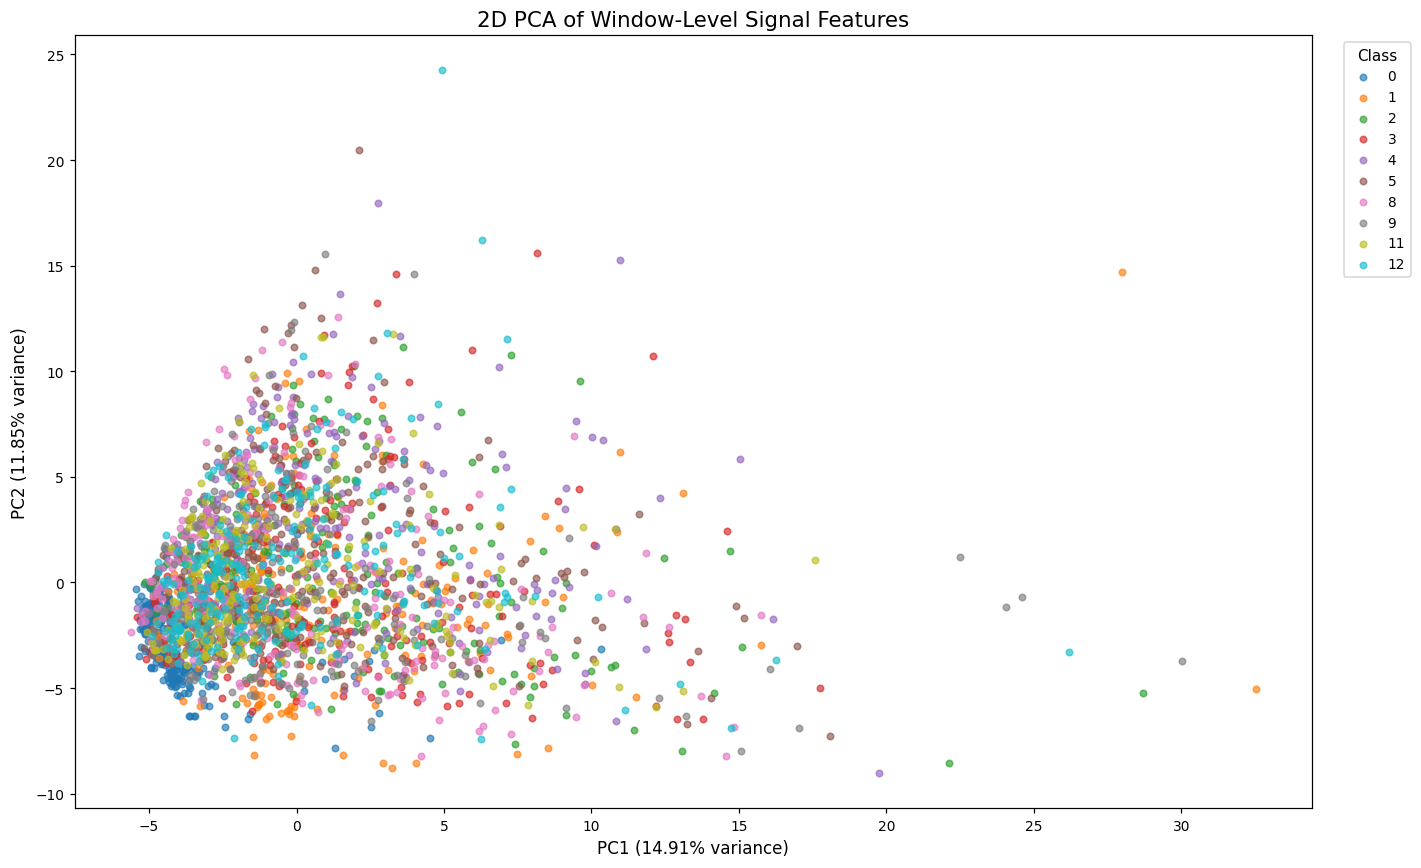

Reading: PC1 and PC2 explain 26.76% of variance. Distinct clusters suggest separability; overlap suggests that nonlinear relationships or richer temporal features may be needed.


In [35]:
fig, ax = plt.subplots(figsize=(13, 8))

for label, group in embedding_df.groupby("class_label"):
    ax.scatter(
        group["PCA1"],
        group["PCA2"],
        s=18,
        alpha=0.65,
        label=str(label)
    )

ax.set_title("2D PCA of Window-Level Signal Features")
ax.set_xlabel(f"PC1 ({explained[0]:.2f}% variance)")
ax.set_ylabel(f"PC2 ({explained[1]:.2f}% variance)")
ax.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

print(
    f"Reading: PC1 and PC2 explain {explained[:2].sum():.2f}% of variance. "
    "Distinct clusters suggest separability; overlap suggests that nonlinear "
    "relationships or richer temporal features may be needed."
)

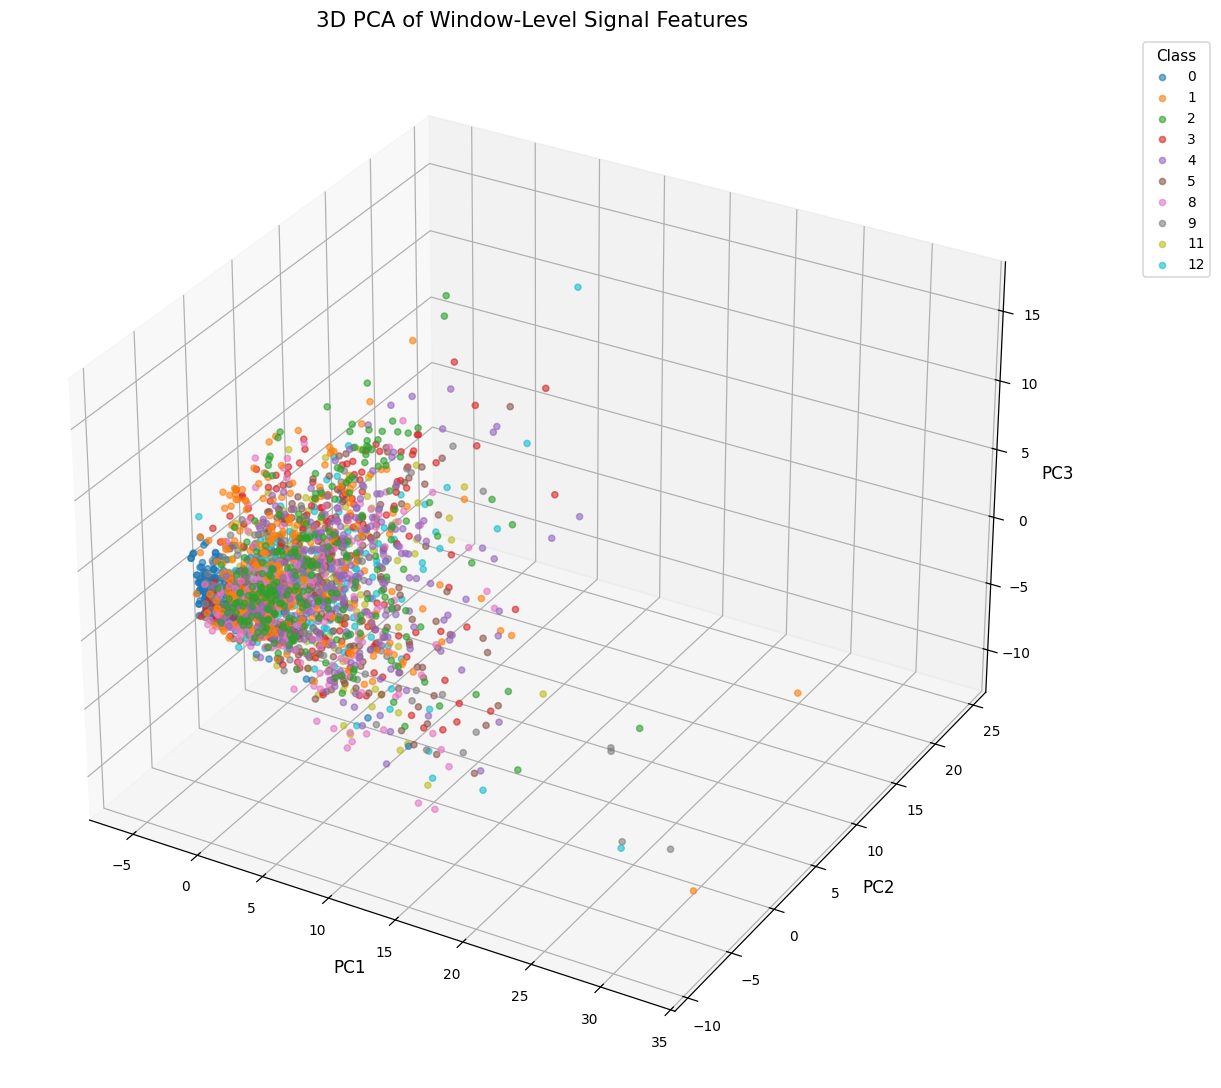

Reading: the third component can reveal separation that is hidden in the two-dimensional PCA view.


In [36]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

for label, group in embedding_df.groupby("class_label"):
    ax.scatter(
        group["PCA1"],
        group["PCA2"],
        group["PCA3"],
        s=16,
        alpha=0.60,
        label=str(label)
    )

ax.set_title("3D PCA of Window-Level Signal Features")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend(title="Class", bbox_to_anchor=(1.08, 1), loc="upper left")

plt.tight_layout()
plt.show()

print(
    "Reading: the third component can reveal separation that is hidden in the "
    "two-dimensional PCA view."
)

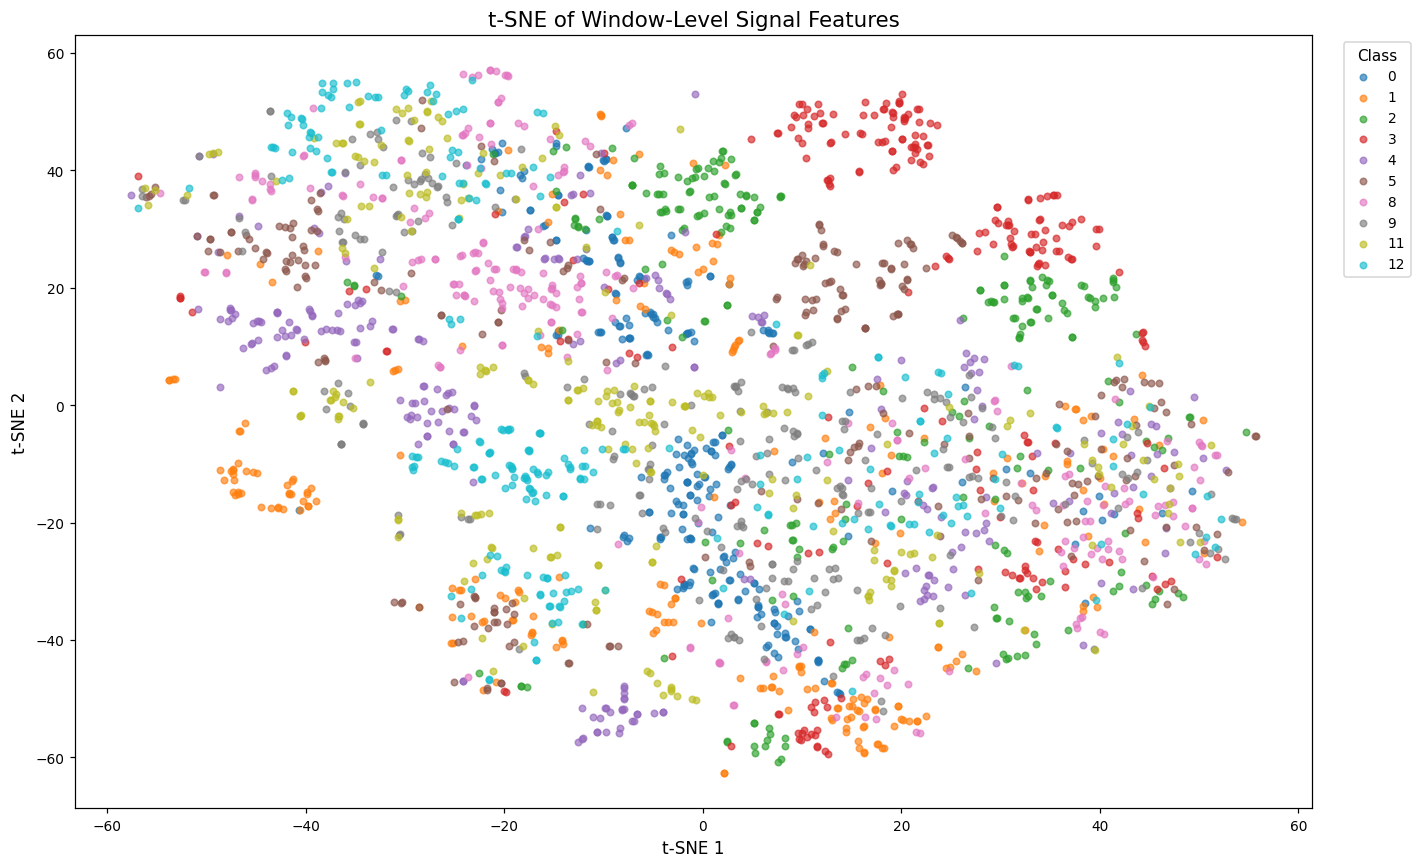

Reading: compact class-specific regions suggest local similarity. t-SNE distances between separate clusters should not be interpreted as global quantitative distances.


In [38]:
tsne_sample = embedding_df.sample(
    n=min(5000, len(embedding_df)),
    random_state=RANDOM_STATE
).copy()

tsne_indices = tsne_sample.index
X_tsne = X_scaled[tsne_indices]

tsne = TSNE(
    n_components=2,
    perplexity=min(30, max(5, len(tsne_sample) // 50)),
    init="pca",
    learning_rate="auto",
    random_state=RANDOM_STATE
)

tsne_values = tsne.fit_transform(X_tsne)
tsne_sample["TSNE1"] = tsne_values[:, 0]
tsne_sample["TSNE2"] = tsne_values[:, 1]

fig, ax = plt.subplots(figsize=(13, 8))

for label, group in tsne_sample.groupby("class_label"):
    ax.scatter(
        group["TSNE1"],
        group["TSNE2"],
        s=18,
        alpha=0.65,
        label=str(label)
    )

ax.set_title("t-SNE of Window-Level Signal Features")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

print(
    "Reading: compact class-specific regions suggest local similarity. "
    "t-SNE distances between separate clusters should not be interpreted as "
    "global quantitative distances."
)

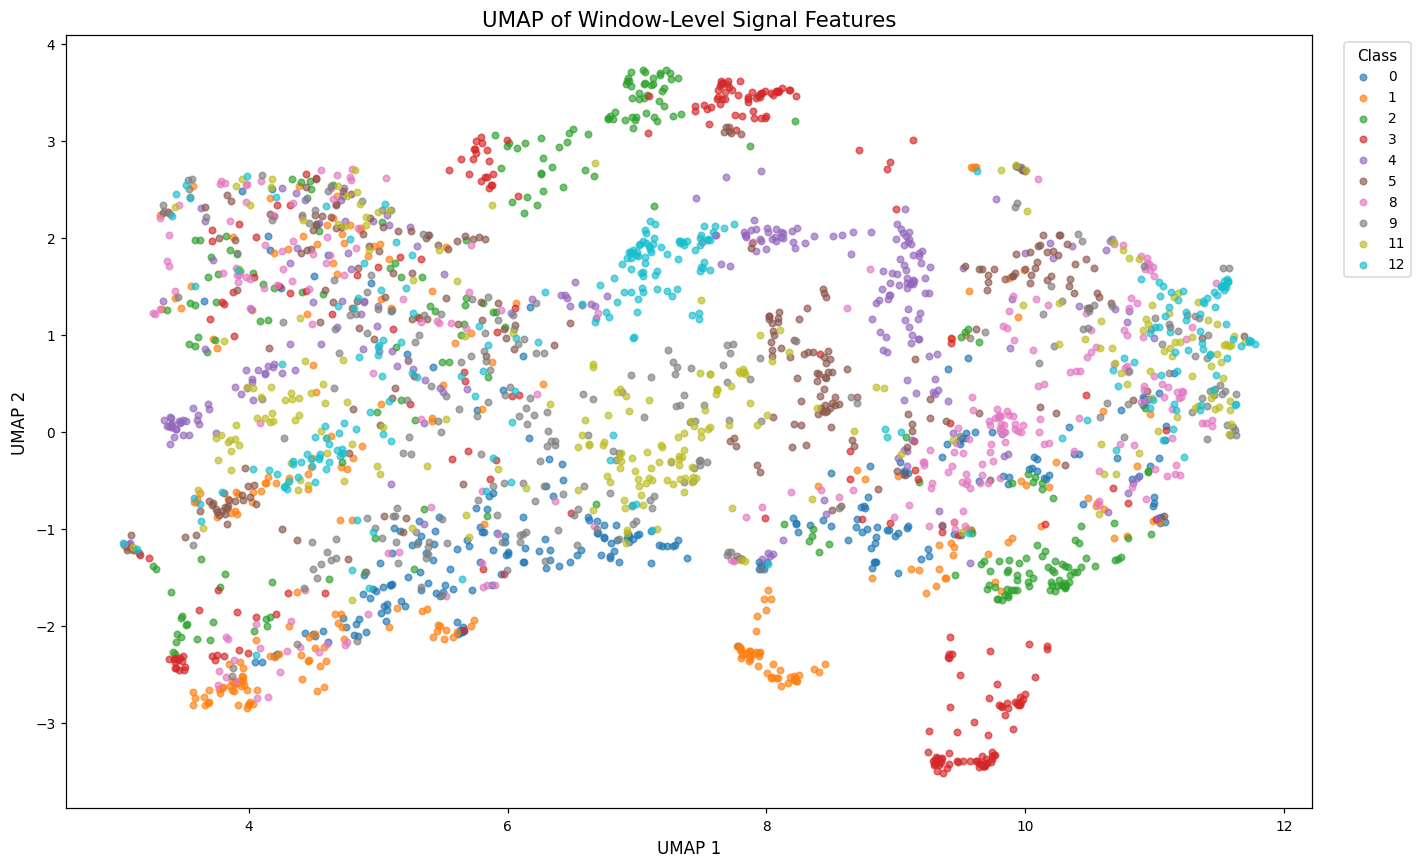

Reading: separated UMAP regions indicate that the window features preserve movement-related structure; mixing indicates substantial class overlap.


In [39]:
try:
    import umap.umap_ as umap
except ImportError:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "umap-learn"
    ])
    import umap.umap_ as umap

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.10,
    random_state=RANDOM_STATE
)

umap_values = umap_model.fit_transform(X_scaled)

embedding_df["UMAP1"] = umap_values[:, 0]
embedding_df["UMAP2"] = umap_values[:, 1]

fig, ax = plt.subplots(figsize=(13, 8))

for label, group in embedding_df.groupby("class_label"):
    ax.scatter(
        group["UMAP1"],
        group["UMAP2"],
        s=18,
        alpha=0.65,
        label=str(label)
    )

ax.set_title("UMAP of Window-Level Signal Features")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

print(
    "Reading: separated UMAP regions indicate that the window features preserve "
    "movement-related structure; mixing indicates substantial class overlap."
)

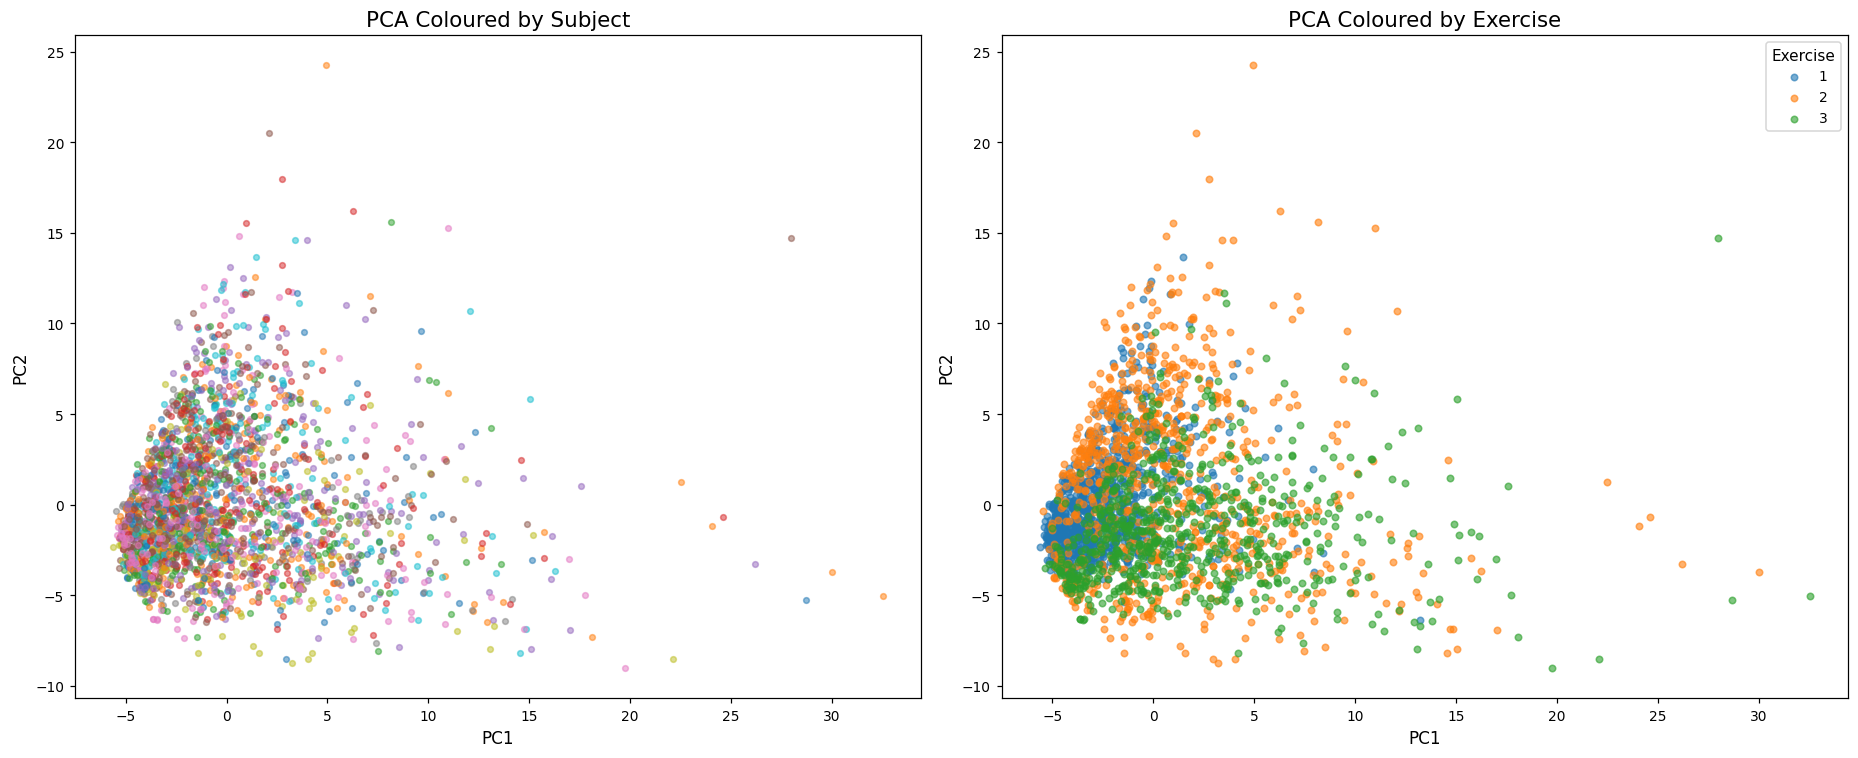

Reading: grouping by subject rather than movement would indicate a strong subject effect. Exercise grouping may reflect different movement families.


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

for subject, group in embedding_df.groupby("subject_id"):
    axes[0].scatter(
        group["PCA1"],
        group["PCA2"],
        s=14,
        alpha=0.50,
        label=str(int(subject))
    )

axes[0].set_title("PCA Coloured by Subject")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

for exercise, group in embedding_df.groupby("exercise_id"):
    axes[1].scatter(
        group["PCA1"],
        group["PCA2"],
        s=18,
        alpha=0.60,
        label=str(int(exercise))
    )

axes[1].set_title("PCA Coloured by Exercise")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(title="Exercise")

plt.tight_layout()
plt.show()

print(
    "Reading: grouping by subject rather than movement would indicate a strong "
    "subject effect. Exercise grouping may reflect different movement families."
)

# H. Interactive plots

Use the toolbar to zoom, pan, rotate, and inspect exact values. These outputs are best preserved by saving the executed notebook and exporting it as HTML.

In [41]:
interactive_balance = px.bar(
    class_balance_df,
    x=class_balance_df["Class"].astype(str),
    y="Samples",
    hover_data={
        "Percentage": ":.3f",
        "Duration_min": ":.2f"
    },
    title="Interactive Class Distribution"
)

interactive_balance.update_layout(
    xaxis_title="Class label",
    yaxis_title="Number of samples",
    height=550
)
interactive_balance.show()

print(
    f"Reading: rest accounts for {rest_percentage:.2f}% of the dataset, while "
    f"the active-class imbalance ratio is {imbalance_ratio:.2f}."
)

Reading: rest accounts for 58.08% of the dataset, while the active-class imbalance ratio is 2.89.


In [42]:
interactive_key = display_layout["signals"][0]
interactive_matrix = np.asarray(display_data[interactive_key])
interactive_length = min(2500, len(interactive_matrix))
interactive_channels = min(5, interactive_matrix.shape[1])

interactive_signal_df = pd.DataFrame({
    "Time_s": np.arange(interactive_length) / SAMPLING_RATE_HZ
})

for channel in range(interactive_channels):
    interactive_signal_df[f"Channel {channel + 1}"] = (
        interactive_matrix[:interactive_length, channel]
    )

interactive_long = interactive_signal_df.melt(
    id_vars="Time_s",
    var_name="Channel",
    value_name="Signal"
)

interactive_signal = px.line(
    interactive_long,
    x="Time_s",
    y="Signal",
    color="Channel",
    title=f"Interactive Signal Viewer: {display_file.name} — {interactive_key}"
)

interactive_signal.update_layout(
    xaxis_title="Time (seconds)",
    yaxis_title="Signal value",
    height=600
)
interactive_signal.show()

print(
    "Reading: zoom into movement transitions to inspect signal bursts, flat "
    "segments, noise, and channel-to-channel differences."
)

Reading: zoom into movement transitions to inspect signal bursts, flat segments, noise, and channel-to-channel differences.


In [43]:
interactive_pca = px.scatter_3d(
    embedding_df,
    x="PCA1",
    y="PCA2",
    z="PCA3",
    color=embedding_df["class_label"].astype(str),
    hover_data=["subject_id", "exercise_id", "repetition", "file"],
    title="Interactive 3D PCA of Window-Level Features"
)

interactive_pca.update_traces(marker={"size": 3, "opacity": 0.65})
interactive_pca.update_layout(
    legend_title_text="Class",
    height=750
)
interactive_pca.show()

print(
    "Reading: rotate the plot to check whether apparently overlapping classes "
    "separate from another angle and whether points from the same subject cluster."
)

Reading: rotate the plot to check whether apparently overlapping classes separate from another angle and whether points from the same subject cluster.


In [44]:
interactive_corr = go.Figure(
    data=go.Heatmap(
        z=correlation_matrix.values,
        x=correlation_matrix.columns,
        y=correlation_matrix.index,
        zmin=-1,
        zmax=1,
        colorbar={"title": "r"}
    )
)

interactive_corr.update_layout(
    title="Interactive Feature Correlation Heatmap",
    xaxis_title="Feature",
    yaxis_title="Feature",
    height=850,
    width=950
)
interactive_corr.show()

print(
    f"Reading: {len(redundant_features_df)} feature pairs have |r| ≥ 0.95. "
    "Hover over a cell to inspect its exact correlation."
)

Reading: 0 feature pairs have |r| ≥ 0.95. Hover over a cell to inspect its exact correlation.


# Final EDA summary and next-step evidence

In [45]:
final_summary_df = pd.DataFrame({
    "Evidence": [
        "Files analyzed",
        "Subjects",
        "Exercises",
        "Active movement classes",
        "Total raw samples",
        "Missing values",
        "Infinite values",
        "Unsynchronized files",
        "Duplicate files",
        "Duplicate signal rows",
        "Near-constant features",
        "Highly correlated feature pairs",
        "Rest proportion",
        "Active-class imbalance ratio",
        "PCA variance in first 2 components"
    ],
    "Result": [
        len(inventory_df),
        int(inventory_df["subject_id"].nunique()),
        int(inventory_df["exercise_id"].nunique()),
        len(active_classes),
        int(inventory_df["Samples"].sum()),
        int(inventory_df["Missing_values"].sum()),
        int(inventory_df["Infinite_values"].sum()),
        int((~inventory_df["Aligned"]).sum()),
        duplicate_file_count,
        int(inventory_df["Duplicate_signal_rows"].sum()),
        len(near_constant_features),
        len(redundant_features_df),
        f"{rest_percentage:.2f}%",
        f"{imbalance_ratio:.2f}",
        f"{explained[:2].sum():.2f}%"
    ]
})

display(final_summary_df)

,Evidence,Result
0,Files analyzed,81
1,Subjects,27
2,Exercises,3
3,Active movement classes,23
4,Total raw samples,12553611
5,Missing values,0
6,Infinite values,0
7,Unsynchronized files,0
8,Duplicate files,0
9,Duplicate signal rows,232255


## How the EDA supports the next project decision

Use the actual outputs above when discussing the next step with the teacher:

- **Movement classification:** supported when movement classes show useful separation in the distribution and embedding plots.
- **Hand-pose regression:** supported when glove signals vary smoothly and show meaningful synchronized relationships with EMG.
- **Within-subject modelling:** suitable when repetitions are consistent within a subject but subjects have noticeably different signal ranges.
- **Cross-subject generalization:** meaningful but challenging when PCA and subject-level comparisons show strong subject-specific structure.
- **Exercise-specific modelling:** suitable when the three exercises produce clearly different feature regions or class behaviours.
- **Feature reduction:** justified when many channels or window features are near-constant or highly correlated.

The final recommendation should refer to evidence such as class overlap, subject variability, repetition consistency, class imbalance, signal quality, and EMG–glove relationships rather than selecting a modelling track in advance.

## Submission checklist

1. Run all cells successfully.
2. Confirm that every table and figure is visible.
3. Save the executed notebook.
4. Download the `.ipynb` file.
5. Export an HTML copy so the outputs and interactive Plotly figures are easy to view.